# CrimeScope FBI — Final Combined Analysis
### FBI NIBRS Big Data | ALY 6110 Group Project

**Team:** Neeti Shah · Sukrit Tripathi · Edison · Khue Dinh  
**Course:** ALY 6110 — Big Data Analysis, Northeastern University  
**Data Source:** [FBI Crime Data Explorer — NIBRS](https://cde.fbi.gov/dataexplorer)  
**GitHub:** [ALY_6110](https://github.com/sukritt87/ALY_6110)

---

## Project Overview

This notebook integrates all four individual contributions into a single end-to-end pipeline:

| Section | Contributor | Task |
|---------|------------|------|
| §5 — Crime Classification | Neeti Shah | Predict crime_against (Person/Property/Society) |
| §6 — Offense Category Prediction | Sukrit Tripathi | Predict specific offense category |
| §7 — Arrest Prediction | Edison | Binary arrest likelihood (ROC-AUC focus) |
| §8 — Monthly Forecasting | Khue Dinh | Ridge regression + patrol allocation LP |

**Data:** 5.4M+ offense records · 4 states (CA, MA, NJ, ID) · 4 years (2021–2024)  
**Pipeline:** Multi-table relational join · Leakage-safe features · Full evaluation suite

## Table of Contents
1. [Imports](#1-imports)
2. [Auto-Download FBI Data](#2-auto-download-fbi-data)
3. [Configuration](#3-configuration)
4. [Data Loading & Join Architecture](#4-data-loading--join-architecture)
5. [Exploratory Data Analysis](#5-exploratory-data-analysis)
6. [Neeti — Crime Classification](#6-neeti--crime-classification)
7. [Sukrit — Offense Category Prediction](#7-sukrit--offense-category-prediction)
8. [Edison — Arrest Prediction](#8-edison--arrest-prediction)
9. [Khue — Forecasting & Patrol Allocation](#9-khue--forecasting--patrol-allocation)
10. [Combined Model Comparison](#10-combined-model-comparison)


## 1. Imports

In [1]:
from __future__ import annotations

import re
import warnings
import zipfile
from io import BytesIO
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder, StandardScaler, LabelEncoder,
    LabelBinarizer, label_binarize,
)
from sklearn.impute import SimpleImputer
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, auc as sklearn_auc,
    classification_report, ConfusionMatrixDisplay,
)
from sklearn.linear_model import LogisticRegression, RidgeClassifier, Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

try:
    from scipy.optimize import linprog
    from scipy.special import softmax as sp_softmax
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False
    warnings.warn("SciPy not found — patrol allocation section will be skipped.")

try:
    import requests
    REQUESTS_OK = True
except ImportError:
    REQUESTS_OK = False

import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 12})
print(f"✅ Libraries loaded. SciPy available: {SCIPY_AVAILABLE}")


✅ Libraries loaded. SciPy available: True


## 2. Auto-Download FBI Data

In [2]:
# ── FBI NIBRS Data Setup ──────────────────────────────────────────────────
#
# The FBI Crime Data Explorer does NOT provide a public programmatic
# download API. Data must be downloaded manually from the portal.
#
# STEP-BY-STEP DOWNLOAD INSTRUCTIONS:
# ─────────────────────────────────────────────────────────────────────────
# 1. Go to: https://cde.ucr.cjis.gov/LATEST/webapp/#/pages/downloads
# 2. Under "NIBRS" section, select each combination:
#       States: California (CA), Massachusetts (MA), New Jersey (NJ), Idaho (ID)
#       Years:  2021, 2022, 2023, 2024
# 3. Click Download for each state-year combination (16 downloads total)
# 4. Each download is a .zip file — extract each one
# 5. Rename each extracted folder as:  STATE-YEAR
#       Examples:  CA-2021   MA-2022   NJ-2023   ID-2024
# 6. Place all 16 folders inside ONE parent folder, e.g.:
#       C:/Users/neeti/nibrs_data/
#               ├── CA-2021/
#               ├── CA-2022/
#               ├── ...
#               └── ID-2024/
# 7. Update BASE_DIR in Section 3 to that parent folder path
#
# ── Verify folder structure is correct ────────────────────────────────────

from pathlib import Path
import re

# ← UPDATE to match wherever you stored your data
BASE_DIR_CHECK = Path(r"C:\Users\neeti\OneDrive\Desktop\NEU\ALY 6110\ALY_6110\ALY_6110")

pat = re.compile(r'^[A-Z]{2}-\d{4}$')

if not BASE_DIR_CHECK.exists():
    print(f"⚠️  Path does not exist: {BASE_DIR_CHECK}")
    print("   Update BASE_DIR_CHECK above and BASE_DIR in Section 3.")
else:
    found = sorted([p.name for p in BASE_DIR_CHECK.iterdir()
                    if p.is_dir() and pat.match(p.name)])
    if found:
        print(f"✅ Found {len(found)} state-year folders:")
        for f in found:
            print(f"   {f}")
    else:
        print(f"⚠️  No STATE-YEAR folders found in: {BASE_DIR_CHECK}")
        print("   Make sure folders are named exactly like: CA-2021, MA-2023, etc.")


✅ Found 16 state-year folders:
   CA-2021
   CA-2022
   CA-2023
   CA-2024
   ID-2021
   ID-2022
   ID-2023
   ID-2024
   MA-2021
   MA-2022
   MA-2023
   MA-2024
   NJ-2021
   NJ-2022
   NJ-2023
   NJ-2024


## 3. Configuration

In [3]:
# Update BASE_DIR to the folder containing state-year sub-folders.
# If you used auto-download above, set BASE_DIR = DOWNLOAD_DIR.
BASE_DIR = Path(
    r"C:\Users\neeti\OneDrive\Desktop\NEU\ALY 6110\ALY_6110\ALY_6110"
)
# BASE_DIR = DOWNLOAD_DIR   # ← uncomment if you used auto-download

MAX_ROWS     = 250_000
TEST_SIZE    = 0.20
RANDOM_STATE = 42

FACT_FILES = {
    'incident':      'NIBRS_INCIDENT.csv',
    'offense':       'NIBRS_OFFENSE.csv',
    'victim':        'NIBRS_VICTIM.csv',
    'offender':      'NIBRS_OFFENDER.csv',
    'arrestee':      'NIBRS_ARRESTEE.csv',
    'victim_offense':'NIBRS_VICTIM_OFFENSE.csv',
    'weapon':        'NIBRS_WEAPON.csv',
}
LOOKUP_FILES = {
    'offense_type':  'NIBRS_OFFENSE_TYPE.csv',
    'location_type': 'NIBRS_LOCATION_TYPE.csv',
    'race':          'REF_RACE.csv',
    'ethnicity':     'NIBRS_ETHNICITY.csv',
    'month':         'NIBRS_MONTH.csv',
}
READ_KWARGS = dict(dtype=str, low_memory=False)

OUTPUT_DIR = Path('model_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"BASE_DIR: {BASE_DIR}")
print(f"MAX_ROWS: {MAX_ROWS:,}  |  TEST_SIZE: {TEST_SIZE}  |  RANDOM_STATE: {RANDOM_STATE}")


BASE_DIR: C:\Users\neeti\OneDrive\Desktop\NEU\ALY 6110\ALY_6110\ALY_6110
MAX_ROWS: 250,000  |  TEST_SIZE: 0.2  |  RANDOM_STATE: 42


## 4. Data Loading & Join Architecture

In [4]:
def find_state_year_dirs(base_dir: Path) -> List[Tuple[Path, str, int]]:
    pat = re.compile(r'^[A-Z]{2}-\d{4}$')
    dirs = []
    for p in base_dir.iterdir():
        if p.is_dir() and pat.match(p.name):
            st, yr = p.name.split('-')
            dirs.append((p, st, int(yr)))
    dirs.sort(key=lambda x: (x[1], x[2]))
    return dirs


def load_fact_table(state_year_dirs, file_name: str) -> pd.DataFrame:
    frames = []
    for folder, st, yr in state_year_dirs:
        fp = folder / file_name
        if not fp.exists():
            continue
        df = pd.read_csv(fp, **READ_KWARGS)
        df.columns = [c.strip().lower() for c in df.columns]
        df['state'] = st
        df['year']  = yr
        frames.append(df)
    if not frames:
        raise FileNotFoundError(f'No files found for {file_name}.')
    return pd.concat(frames, ignore_index=True)


def load_lookup_table(state_year_dirs, file_name: str) -> pd.DataFrame:
    for folder, _, _ in state_year_dirs:
        fp = folder / file_name
        if fp.exists():
            df = pd.read_csv(fp, **READ_KWARGS)
            df.columns = [c.strip().lower() for c in df.columns]
            return df
    raise FileNotFoundError(f'Lookup not found: {file_name}')


def coerce_numeric(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors='coerce')


def sample_for_models(df: pd.DataFrame, max_rows: int, seed: int = 42) -> pd.DataFrame:
    if len(df) <= max_rows:
        return df
    return df.sample(n=max_rows, random_state=seed).reset_index(drop=True)


def build_offense_view(state_year_dirs) -> pd.DataFrame:
    """Constructs the core analytical frame joining NIBRS tables.
    offense_category_name and crime_against are retained for EDA and
    contributor models; Neeti's section excludes both to prevent leakage.
    """
    df_incident = load_fact_table(state_year_dirs, FACT_FILES['incident'])
    df_offense  = load_fact_table(state_year_dirs, FACT_FILES['offense'])
    lk_offense_type  = load_lookup_table(state_year_dirs, LOOKUP_FILES['offense_type'])
    lk_location_type = load_lookup_table(state_year_dirs, LOOKUP_FILES['location_type'])
    lk_month         = load_lookup_table(state_year_dirs, LOOKUP_FILES['month'])

    view = df_offense.merge(
        lk_offense_type[['offense_code','offense_name','offense_category_name','crime_against']],
        on='offense_code', how='left', validate='m:1'
    )
    view = view.merge(
        lk_location_type[['location_id','location_name']],
        on='location_id', how='left', validate='m:1'
    )
    view = view.merge(
        df_incident[['incident_id','incident_date','incident_hour','nibrs_month_id','state','year']],
        on=['incident_id','state','year'], how='left', validate='m:1'
    )

    month_cols = [c for c in ['nibrs_month_id','month_num','data_year'] if c in lk_month.columns]
    if 'nibrs_month_id' in month_cols and 'month_num' in month_cols:
        month_lk = lk_month[month_cols].drop_duplicates(subset=['nibrs_month_id'])
        view = view.merge(month_lk, on='nibrs_month_id', how='left', validate='m:1')

    view['incident_date'] = pd.to_datetime(view.get('incident_date'), errors='coerce')
    if 'month_num' not in view.columns:
        view['month_num'] = view['incident_date'].dt.month
    view['month_num_num']     = coerce_numeric(view.get('month_num'))
    view['incident_hour_num'] = coerce_numeric(view.get('incident_hour'))
    view['data_year_num']     = coerce_numeric(view.get('data_year', view.get('year')))

    return view


if not BASE_DIR.exists():
    raise FileNotFoundError(
        f'BASE_DIR not found: {BASE_DIR}\n'
        'Update the path in Section 3 or run Section 2 to auto-download the data.'
    )

state_year_dirs = find_state_year_dirs(BASE_DIR)
print(f'State-year folders: {len(state_year_dirs)}')
for p, st, yr in state_year_dirs:
    print(f'  {p.name}')

print('\nBuilding offense_view — this may take a few minutes on the full dataset...')
offense_view = build_offense_view(state_year_dirs)
print(f'offense_view: {offense_view.shape[0]:,} rows × {offense_view.shape[1]} cols')
offense_view.head(3)


# ── Pre-build monthly_incidents for Khue (parse month from incident_date) ─
# NIBRS_MONTH only covers one state's IDs; incident_date works for all folders.
print("\nBuilding monthly_incidents from incident_date...")
_inc_frames_k = []
for _folder, _st, _yr in state_year_dirs:
    _fp = _folder / "NIBRS_INCIDENT.csv"
    if not _fp.exists():
        continue
    _df = pd.read_csv(_fp, usecols=["incident_date"], dtype=str, low_memory=False)
    _df.columns = ["incident_date"]
    _df["state"] = _st
    _df["yr"]    = int(_yr)
    _inc_frames_k.append(_df)

_incidents_k = pd.concat(_inc_frames_k, ignore_index=True)
_incidents_k["mon"] = pd.to_datetime(
    _incidents_k["incident_date"], errors="coerce").dt.month.astype("Int64")
_incidents_k = _incidents_k.dropna(subset=["mon"])
_incidents_k = _incidents_k[_incidents_k["mon"].between(1, 12)]

monthly_incidents = (
    _incidents_k
    .groupby(["state", "yr", "mon"], as_index=False)
    .size()
    .rename(columns={"size": "crime_count"})
    .sort_values(["state", "yr", "mon"])
    .reset_index(drop=True)
)
monthly_incidents["yr"]  = monthly_incidents["yr"].astype(int)
monthly_incidents["mon"] = monthly_incidents["mon"].astype(int)

print(f"monthly_incidents: {len(monthly_incidents):,} records")
print(f"Years: {sorted(monthly_incidents['yr'].unique())}")
print(f"States: {sorted(monthly_incidents['state'].unique())}")
del _inc_frames_k, _incidents_k  # free memory


State-year folders: 16
  CA-2021
  CA-2022
  CA-2023
  CA-2024
  ID-2021
  ID-2022
  ID-2023
  ID-2024
  MA-2021
  MA-2022
  MA-2023
  MA-2024
  NJ-2021
  NJ-2022
  NJ-2023
  NJ-2024

Building offense_view — this may take a few minutes on the full dataset...
offense_view: 5,472,395 rows × 22 cols

Building monthly_incidents from incident_date...
monthly_incidents: 192 records
Years: [2021, 2022, 2023, 2024]
States: ['CA', 'ID', 'MA', 'NJ']


## 5. Exploratory Data Analysis

### 5a. Offense Trends by State and Year

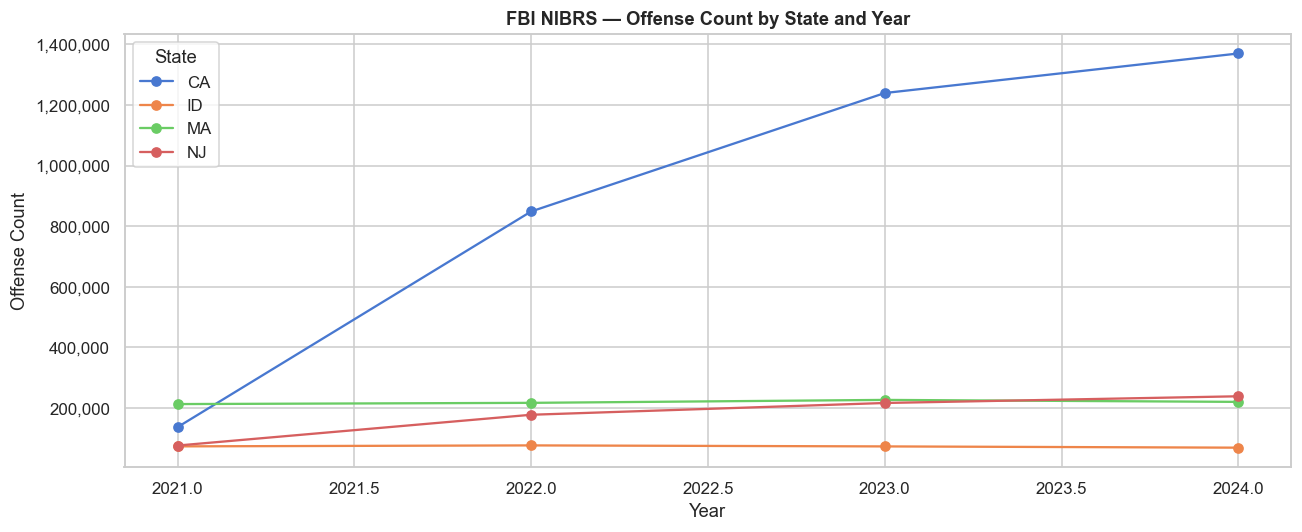

state  data_year_num  offense_count
   CA           2021         136848
   CA           2022         848369
   CA           2023        1239106
   CA           2024        1369571
   ID           2021          73420
   ID           2022          76626
   ID           2023          73294
   ID           2024          69156
   MA           2021         212959
   MA           2022         217004
   MA           2023         226712
   MA           2024         220214
   NJ           2021          76176
   NJ           2022         177702
   NJ           2023         216553
   NJ           2024         238685


In [5]:
state_year_counts = (
    offense_view.dropna(subset=['data_year_num'])
    .groupby(['state', 'data_year_num'])
    .size()
    .reset_index(name='offense_count')
    .sort_values(['state', 'data_year_num'])
)

fig, ax = plt.subplots(figsize=(12, 5))
for state, grp in state_year_counts.groupby('state'):
    ax.plot(grp['data_year_num'], grp['offense_count'], marker='o', label=state)
ax.set_title('FBI NIBRS — Offense Count by State and Year', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Offense Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='State')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_state_year.png', dpi=150, bbox_inches='tight')
plt.show()
print(state_year_counts.to_string(index=False))


### 5b. Top 15 Offense Categories

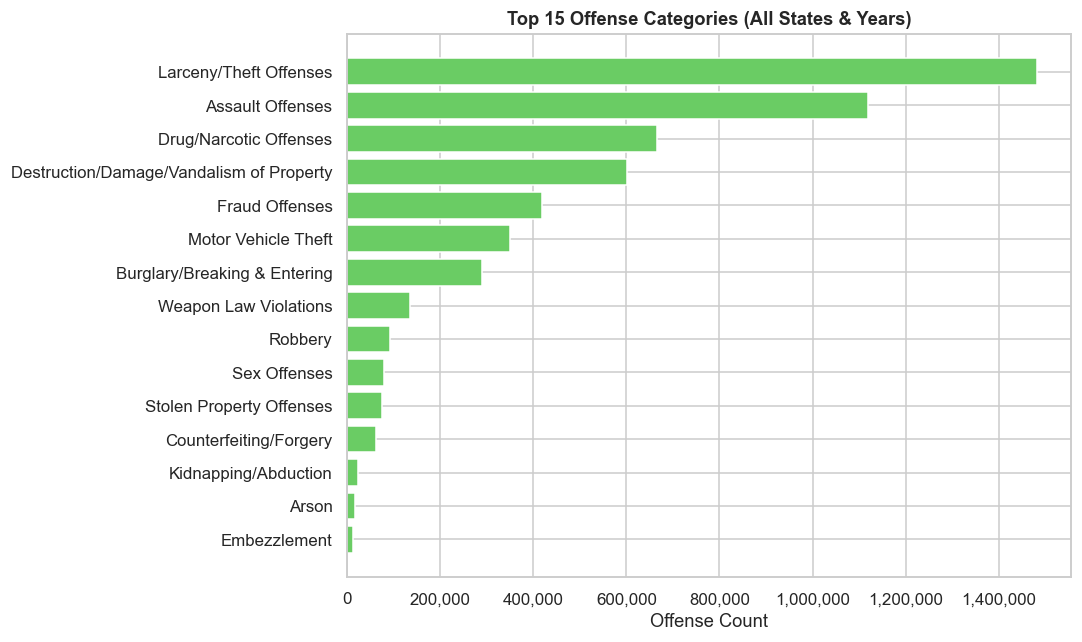

In [6]:
top_cats = (
    offense_view.dropna(subset=['offense_category_name'])
    .groupby('offense_category_name').size()
    .sort_values(ascending=False).head(15)
    .reset_index(name='count').sort_values('count')
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_cats['offense_category_name'], top_cats['count'],
        color=sns.color_palette('muted')[2])
ax.set_title('Top 15 Offense Categories (All States & Years)', fontweight='bold')
ax.set_xlabel('Offense Count')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_top_categories.png', dpi=150, bbox_inches='tight')
plt.show()


### 5c. Crime Against Trends Over Time

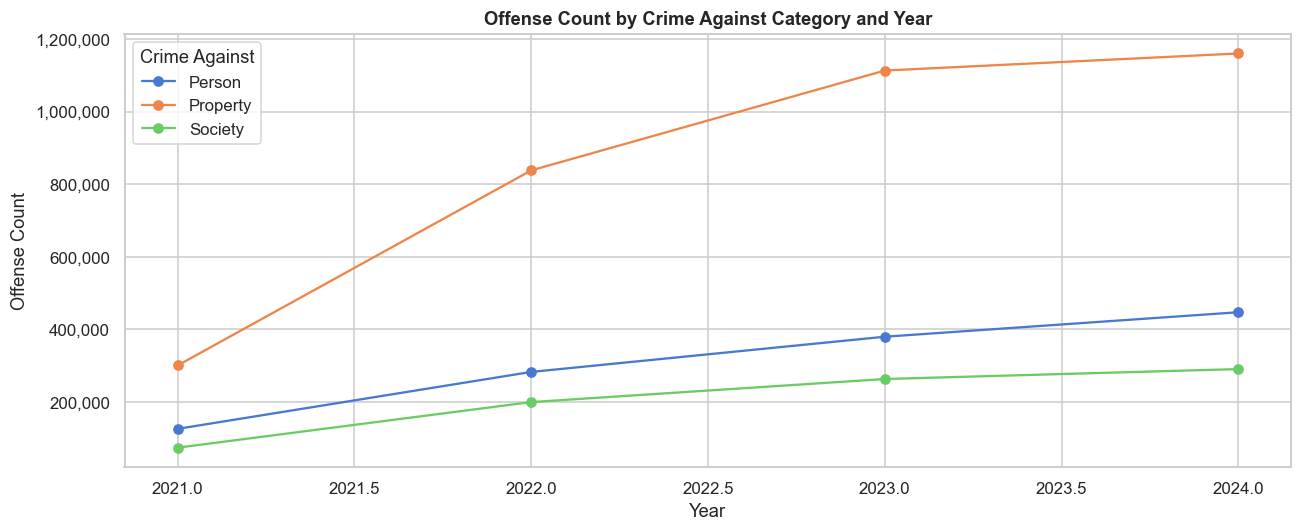

In [7]:
ca_trends = (
    offense_view.dropna(subset=['data_year_num', 'crime_against'])
    .groupby(['data_year_num', 'crime_against']).size()
    .reset_index(name='count')
)

fig, ax = plt.subplots(figsize=(12, 5))
for ca, grp in ca_trends.groupby('crime_against'):
    ax.plot(grp['data_year_num'], grp['count'], marker='o', label=ca)
ax.set_title('Offense Count by Crime Against Category and Year', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Offense Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Crime Against')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_crime_against_trends.png', dpi=150, bbox_inches='tight')
plt.show()


### 5d. Hour-of-Day Distribution

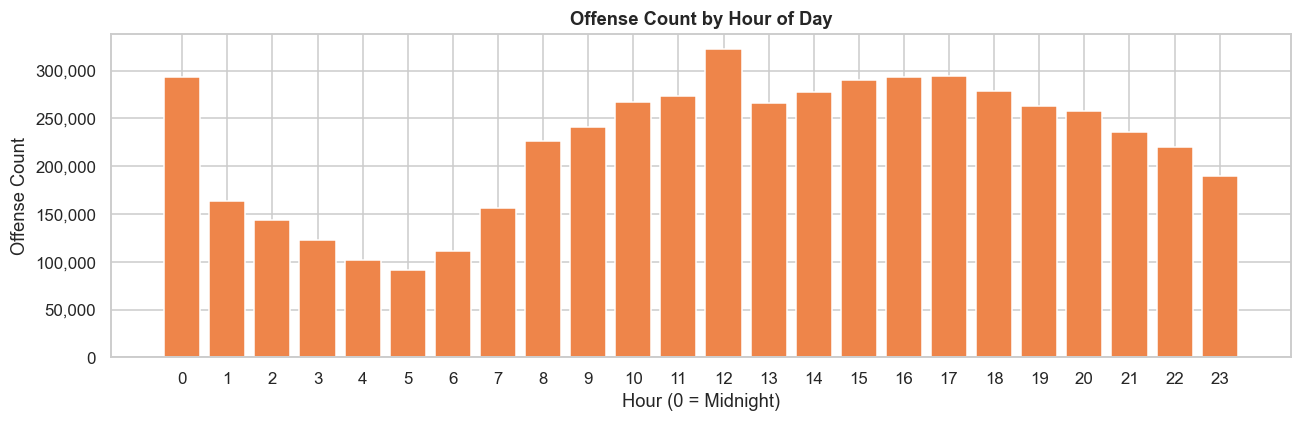

In [8]:
hour_counts = (
    offense_view['incident_hour_num'].dropna().astype(int)
    .value_counts().sort_index()
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hour_counts.index, hour_counts.values,
       color=sns.color_palette('muted')[1], edgecolor='white')
ax.set_title('Offense Count by Hour of Day', fontweight='bold')
ax.set_xlabel('Hour (0 = Midnight)')
ax.set_ylabel('Offense Count')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_hour_dist.png', dpi=150, bbox_inches='tight')
plt.show()


### 5e. Top Location Types by Offense Category

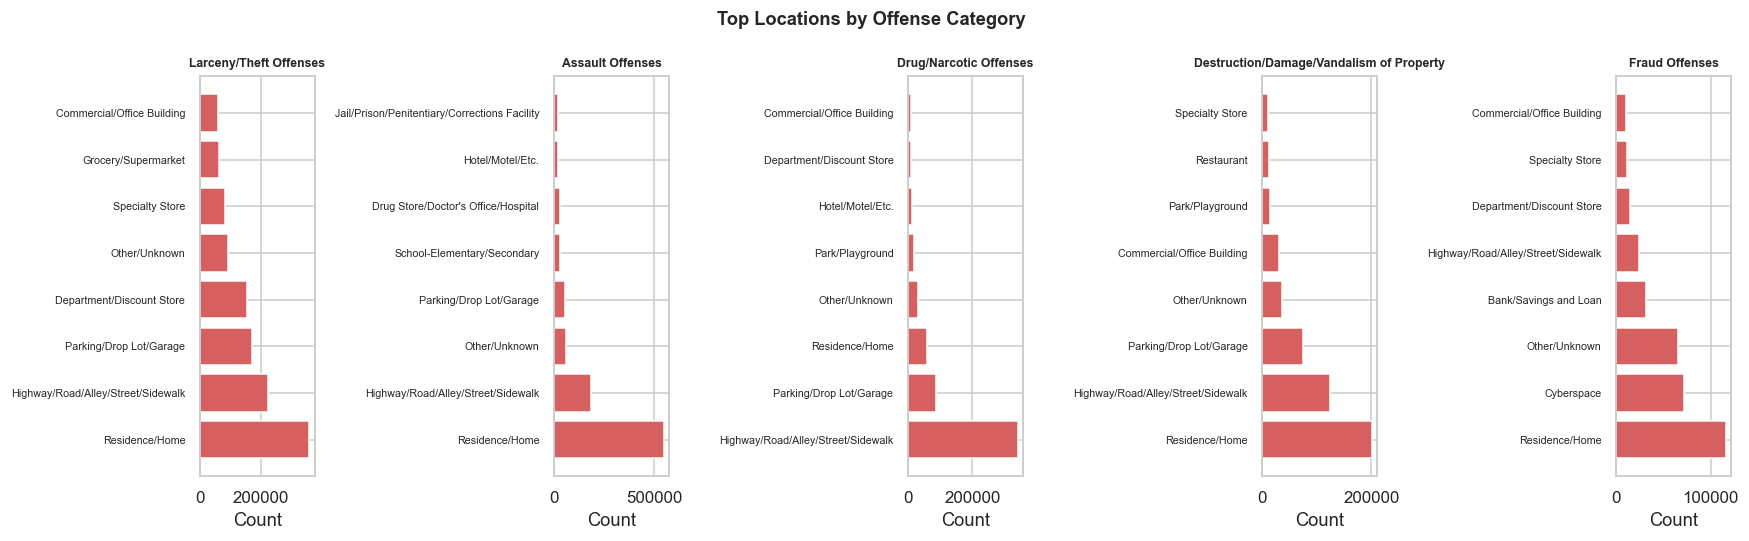

In [9]:
top5_cats = (
    offense_view.groupby('offense_category_name').size()
    .sort_values(ascending=False).head(5).index.tolist()
)

loc_cat = (
    offense_view[offense_view['offense_category_name'].isin(top5_cats)]
    .dropna(subset=['location_name'])
    .groupby(['offense_category_name', 'location_name']).size()
    .reset_index(name='count')
    .sort_values(['offense_category_name', 'count'], ascending=[True, False])
)

fig, axes = plt.subplots(1, len(top5_cats), figsize=(16, 5), sharey=False)
for ax, cat in zip(axes, top5_cats):
    sub = loc_cat[loc_cat['offense_category_name'] == cat].head(8)
    ax.barh(sub['location_name'], sub['count'],
            color=sns.color_palette('muted')[3])
    ax.set_title(cat, fontsize=8, fontweight='bold')
    ax.set_xlabel('Count')
    ax.tick_params(axis='y', labelsize=7)
plt.suptitle('Top Locations by Offense Category', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_locations.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Neeti — Crime Classification Pipeline

**Task:** Classify each offense into Person, Property, or Society using temporal and  
geographic features only — `offense_category_name` excluded to prevent data leakage.

**Models:** Logistic Regression · Ridge Classifier (calibrated) · Decision Tree · Random Forest  
**Metrics:** Accuracy · Macro F1 · ROC-AUC (OVR macro) · Per-class ROC Curves


In [10]:
# ── Preprocessing helpers ─────────────────────────────────────────────────

def build_preprocessor_neeti(X: pd.DataFrame) -> ColumnTransformer:
    cat_cols = [c for c in X.columns if X[c].dtype == 'object']
    num_cols = [c for c in X.columns if c not in cat_cols]
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=True)),
    ])
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler(with_mean=False)),
    ])
    return ColumnTransformer(
        transformers=[('cat', cat_pipe, cat_cols), ('num', num_pipe, num_cols)],
        remainder='drop', sparse_threshold=0.3,
    )


def evaluate_model_neeti(name: str, pipe, X_test, y_test) -> dict:
    """Evaluate a fitted pipeline; handles RidgeClassifier AUC via softmax
    calibration of decision_function scores."""
    preds   = pipe.predict(X_test)
    classes = np.array(sorted(y_test.unique()))

    if hasattr(pipe, 'predict_proba'):
        proba = pipe.predict_proba(X_test)
    elif hasattr(pipe, 'decision_function'):
        raw   = pipe.decision_function(X_test)
        proba = sp_softmax(raw, axis=1) if SCIPY_AVAILABLE else None
    else:
        proba = None

    acc = accuracy_score(y_test, preds)
    f1m = f1_score(y_test, preds, average='macro')
    auc_val = (
        roc_auc_score(y_test, proba, multi_class='ovr', average='macro')
        if proba is not None else float('nan')
    )

    print(f'\n{"="*60}\n  {name}\n{"="*60}')
    print(f'  Accuracy : {acc:.4f}   Macro F1 : {f1m:.4f}   ROC-AUC : {auc_val:.4f}')
    print(classification_report(y_test, preds, digits=4))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, preds,
        normalize='true', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'{name}\nConfusion Matrix', fontweight='bold')

    if proba is not None:
        y_bin = label_binarize(y_test, classes=classes)
        for i, cls in enumerate(classes):
            fpr_c, tpr_c, _ = roc_curve(y_bin[:, i], proba[:, i])
            axes[1].plot(fpr_c, tpr_c, lw=2,
                         label=f'{cls} (AUC={sklearn_auc(fpr_c, tpr_c):.3f})')
        axes[1].plot([0,1],[0,1],'k--',lw=1,label='Random')
        axes[1].set(xlabel='FPR', ylabel='TPR',
                    title=f'{name}\nROC Curves (OVR)')
        axes[1].legend(fontsize=9)
    else:
        axes[1].axis('off')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'neeti_{name.replace(" ","_").lower()}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    return {'model': name, 'contributor': 'Neeti',
            'accuracy': acc, 'macro_f1': f1m, 'roc_auc': auc_val}


def plot_feature_importance_pipe(pipe, top_n=20, title='Feature Importance') -> None:
    prep  = pipe.named_steps['prep']
    model = pipe.named_steps['model']
    # Unwrap CalibratedClassifierCV if needed
    if hasattr(model, 'estimator'):
        model = model.estimator
    if not hasattr(model, 'feature_importances_'):
        print(f'{title}: no feature_importances_ — skipping.')
        return
    importances = model.feature_importances_
    try:
        feature_names = prep.get_feature_names_out()
    except Exception:
        feature_names = None
    if feature_names is not None:
        fi = (pd.DataFrame({'feature': feature_names, 'importance': importances})
                .nlargest(top_n, 'importance').sort_values('importance'))
        fig, ax = plt.subplots(figsize=(9, 7))
        ax.barh(fi['feature'], fi['importance'])
    else:
        idx = np.argsort(importances)[-top_n:]
        fig, ax = plt.subplots(figsize=(9, 7))
        ax.barh([str(i) for i in idx], importances[idx])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Mean Decrease in Impurity')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'fi_{title[:40].replace(" ","_").lower()}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

print("Neeti helper functions defined.")


Neeti helper functions defined.


In [11]:
# ── Feature preparation ────────────────────────────────────────────────────
NEETI_FEATURES = ['state', 'year', 'month_num_num', 'incident_hour_num', 'location_name']
TARGET_COL     = 'crime_against'

neeti_df = offense_view[NEETI_FEATURES + [TARGET_COL]].copy()
neeti_df = neeti_df.dropna(subset=[TARGET_COL])
neeti_df = neeti_df[neeti_df[TARGET_COL].str.strip() != '']
neeti_df['year']              = coerce_numeric(neeti_df['year'])
neeti_df['month_num_num']     = coerce_numeric(neeti_df['month_num_num'])
neeti_df['incident_hour_num'] = coerce_numeric(neeti_df['incident_hour_num'])

print(f"Rows available: {len(neeti_df):,}")
neeti_sample = sample_for_models(neeti_df, MAX_ROWS, RANDOM_STATE)
print(f"Rows used for training: {len(neeti_sample):,}")
print(f"Target distribution:\n{neeti_sample[TARGET_COL].value_counts().to_string()}")

y_n = neeti_sample[TARGET_COL].astype(str)
X_n = neeti_sample[NEETI_FEATURES]

X_n_train, X_n_test, y_n_train, y_n_test = train_test_split(
    X_n, y_n, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_n
)
preprocessor_n = build_preprocessor_neeti(X_n_train)
print(f"\nTrain: {X_n_train.shape[0]:,}  Test: {X_n_test.shape[0]:,}")


Rows available: 5,472,395
Rows used for training: 250,000
Target distribution:
crime_against
Property    155959
Person       56410
Society      37631

Train: 200,000  Test: 50,000



  Logistic Regression
  Accuracy : 0.6402   Macro F1 : 0.3527   ROC-AUC : 0.7173
              precision    recall  f1-score   support

      Person     0.5433    0.0589    0.1063     11282
    Property     0.6420    0.9804    0.7759     31192
     Society     0.6696    0.1012    0.1759      7526

    accuracy                         0.6402     50000
   macro avg     0.6183    0.3802    0.3527     50000
weighted avg     0.6239    0.6402    0.5345     50000



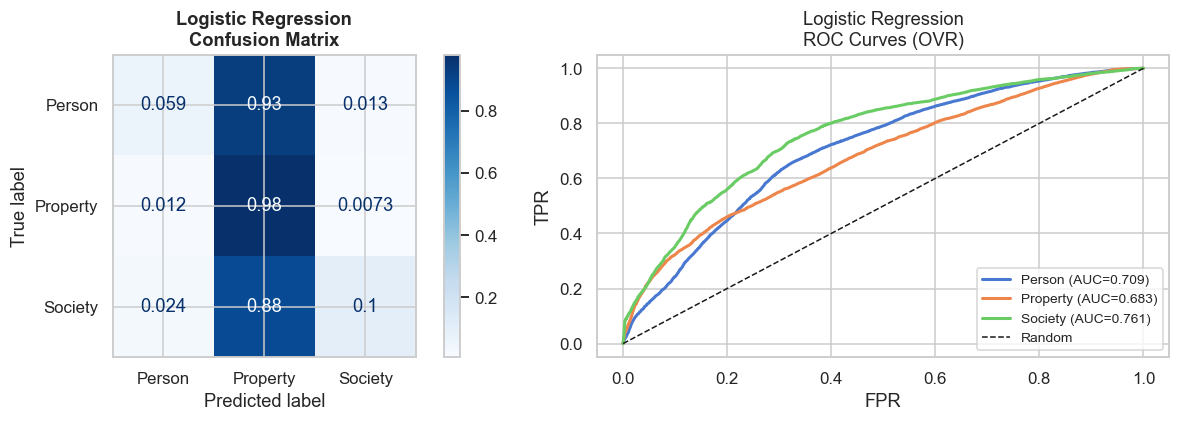


  Ridge Classifier
  Accuracy : 0.6418   Macro F1 : 0.3594   ROC-AUC : 0.7178
              precision    recall  f1-score   support

      Person     0.5191    0.0795    0.1379     11282
    Property     0.6445    0.9779    0.7769     31192
     Society     0.7331    0.0919    0.1634      7526

    accuracy                         0.6418     50000
   macro avg     0.6322    0.3831    0.3594     50000
weighted avg     0.6295    0.6418    0.5404     50000



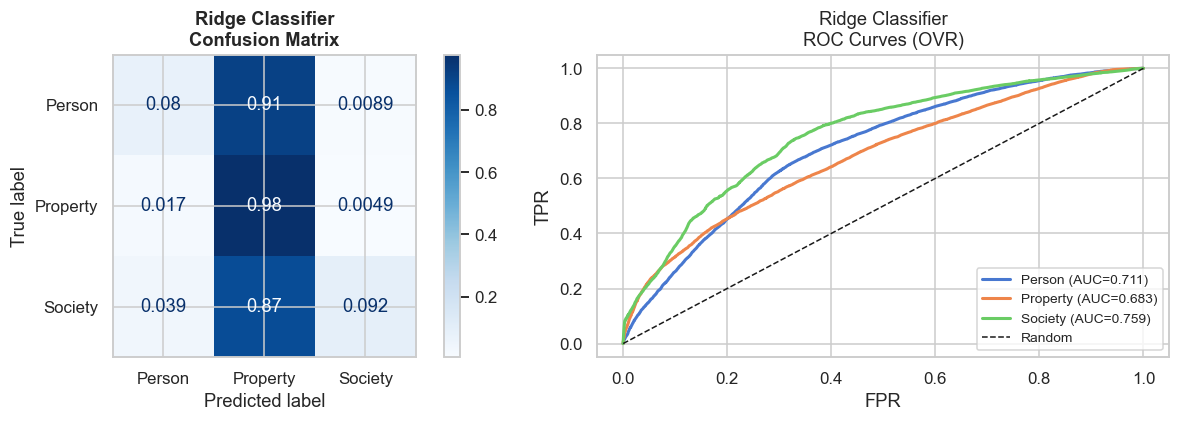


  Decision Tree
  Accuracy : 0.6415   Macro F1 : 0.4152   ROC-AUC : 0.7215
              precision    recall  f1-score   support

      Person     0.4868    0.1736    0.2559     11282
    Property     0.6582    0.9331    0.7719     31192
     Society     0.5738    0.1343    0.2177      7526

    accuracy                         0.6415     50000
   macro avg     0.5729    0.4136    0.4152     50000
weighted avg     0.6068    0.6415    0.5721     50000



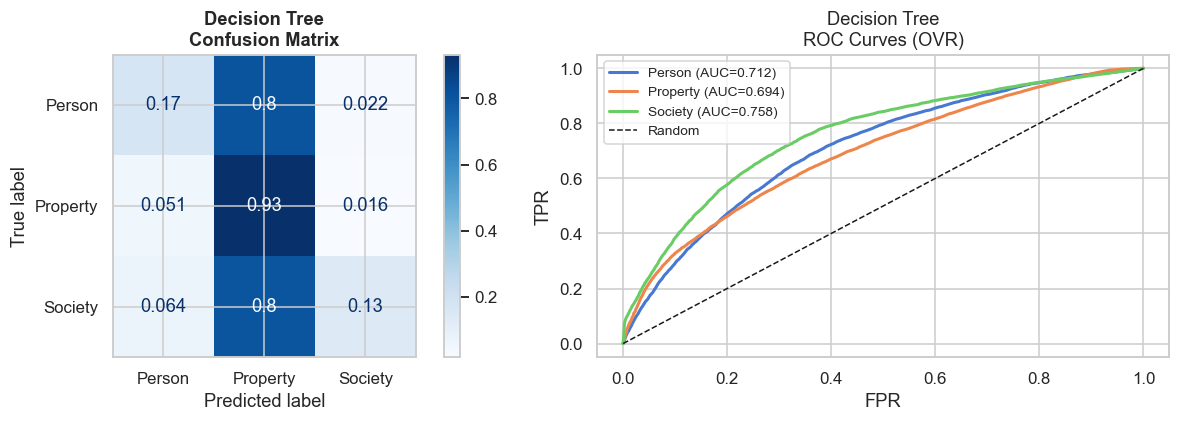

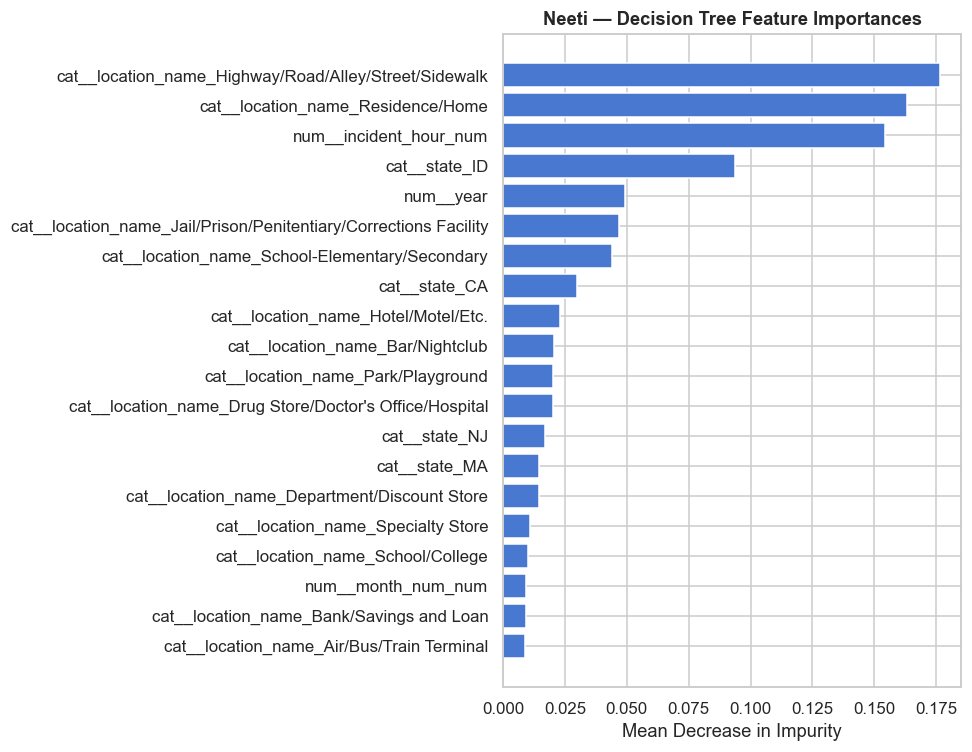


  Random Forest
  Accuracy : 0.6434   Macro F1 : 0.4099   ROC-AUC : 0.7265
              precision    recall  f1-score   support

      Person     0.5004    0.1552    0.2369     11282
    Property     0.6565    0.9428    0.7740     31192
     Society     0.5927    0.1342    0.2189      7526

    accuracy                         0.6434     50000
   macro avg     0.5832    0.4107    0.4099     50000
weighted avg     0.6117    0.6434    0.5693     50000



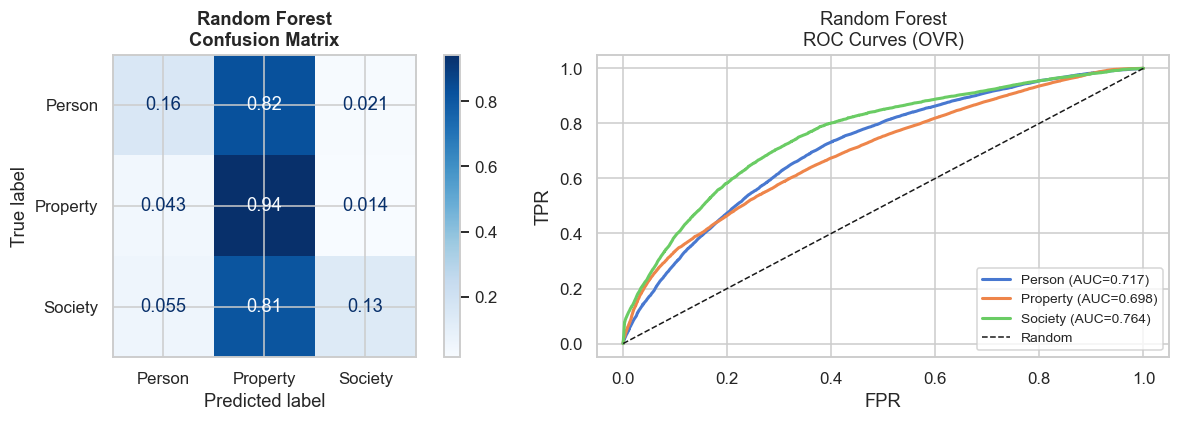

Neeti — Random Forest Feature Importances: no feature_importances_ — skipping.


In [12]:
# ── Model training ────────────────────────────────────────────────────────
neeti_results = []

# Logistic Regression
lr_n = Pipeline([('prep', preprocessor_n),
                  ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])
lr_n.fit(X_n_train, y_n_train)
neeti_results.append(evaluate_model_neeti('Logistic Regression', lr_n, X_n_test, y_n_test))

# Ridge Classifier — wrapped in CalibratedClassifierCV for valid probability scores
ridge_n = Pipeline([
    ('prep',  preprocessor_n),
    ('model', CalibratedClassifierCV(RidgeClassifier(), cv=5, method='sigmoid')),
])
ridge_n.fit(X_n_train, y_n_train)
neeti_results.append(evaluate_model_neeti('Ridge Classifier', ridge_n, X_n_test, y_n_test))

# Decision Tree
dt_n = Pipeline([('prep', preprocessor_n),
                  ('model', DecisionTreeClassifier(random_state=RANDOM_STATE, min_samples_leaf=10))])
dt_n.fit(X_n_train, y_n_train)
neeti_results.append(evaluate_model_neeti('Decision Tree', dt_n, X_n_test, y_n_test))
plot_feature_importance_pipe(dt_n, top_n=20, title='Neeti — Decision Tree Feature Importances')

# Random Forest
rf_n = Pipeline([('prep', preprocessor_n),
                  ('model', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE,
                                                    n_jobs=-1, min_samples_leaf=5))])
rf_n.fit(X_n_train, y_n_train)
neeti_results.append(evaluate_model_neeti('Random Forest', rf_n, X_n_test, y_n_test))
plot_feature_importance_pipe(rf_n, top_n=25, title='Neeti — Random Forest Feature Importances')


## 7. Sukrit — Offense Category Prediction

**Task:** Predict the specific offense category (e.g. Assault, Larceny) from temporal,  
geographic, and crime-against features.  
**Models:** Logistic Regression · Decision Tree · Random Forest · Gradient Boosting


Sukrit model rows: 136,499

  Sukrit — Logistic Regression
  Accuracy : 0.6295   Macro F1 : 0.1605   ROC-AUC : nan
                                          precision    recall  f1-score   support

                          Animal Cruelty     0.0000    0.0000    0.0000         8
                                   Arson     0.0000    0.0000    0.0000        81
                        Assault Offenses     0.9138    1.0000    0.9549      5394
            Burglary/Breaking & Entering     0.5547    0.1467    0.2320      1418
                  Counterfeiting/Forgery     0.0000    0.0000    0.0000       169
Destruction/Damage/Vandalism of Property     0.4031    0.0351    0.0646      2963
                  Drug/Narcotic Offenses     0.8464    0.9991    0.9164      4380
                            Embezzlement     0.0000    0.0000    0.0000        45
                     Extortion/Blackmail     0.0000    0.0000    0.0000        29
                          Fraud Offenses     0.5140    0.3744   

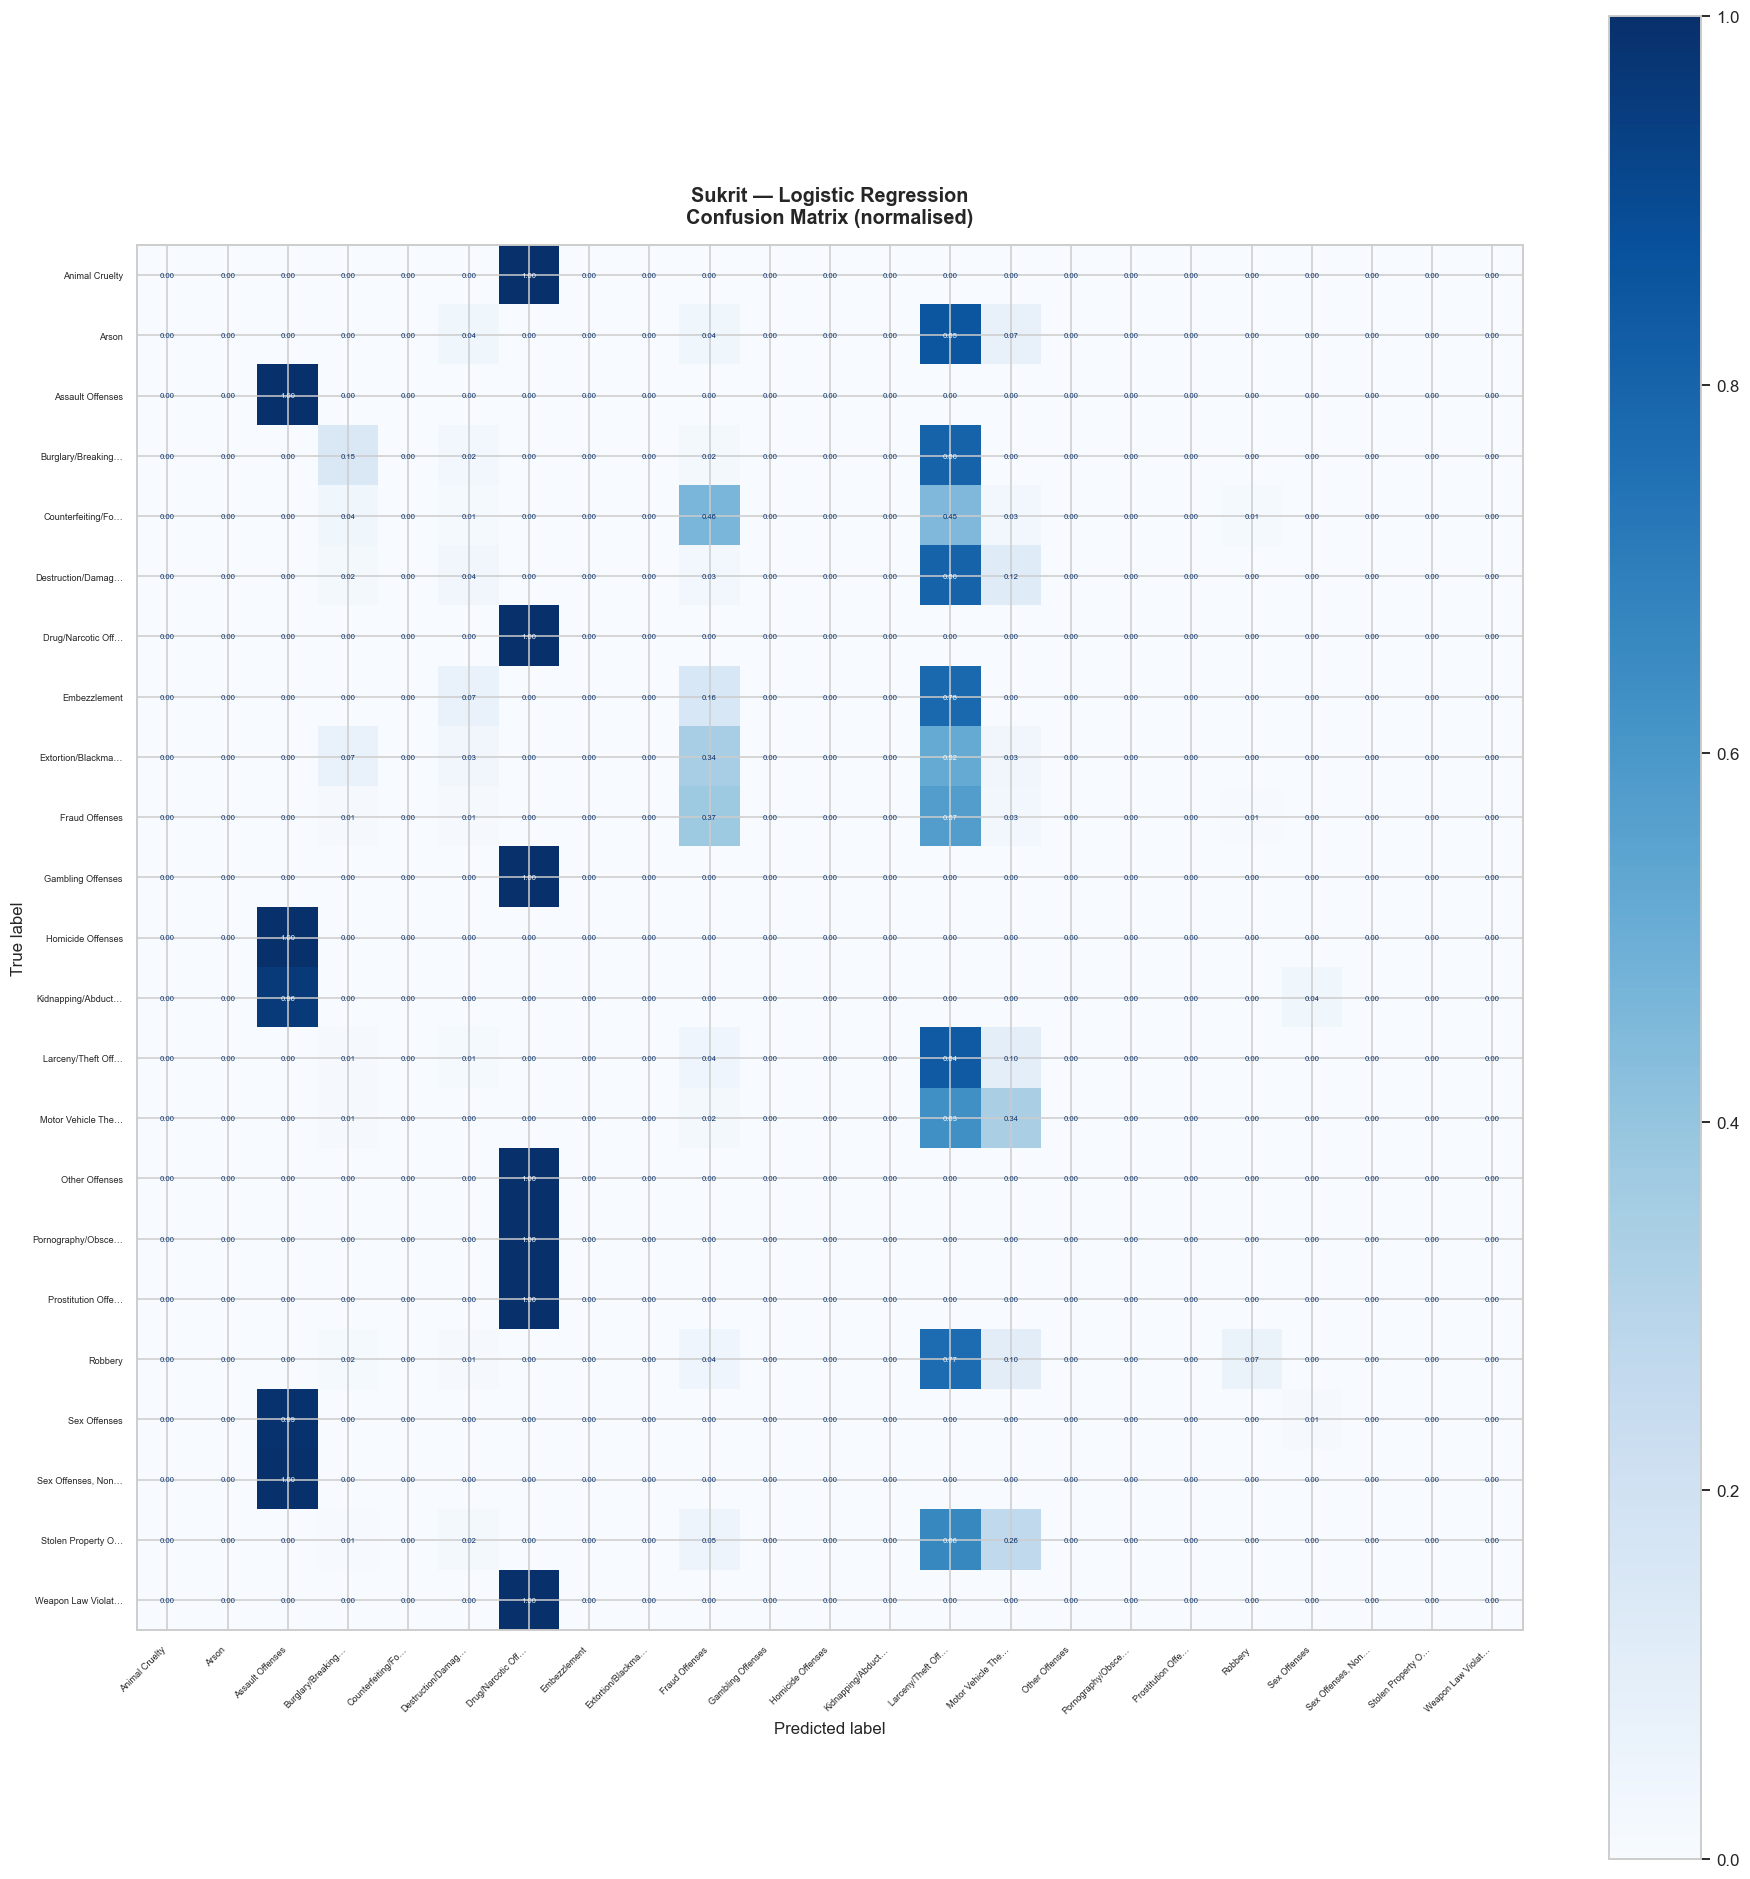


  Sukrit — Decision Tree
  Accuracy : 0.6193   Macro F1 : 0.2082   ROC-AUC : nan
                                          precision    recall  f1-score   support

                          Animal Cruelty     0.0000    0.0000    0.0000         8
                                   Arson     0.0000    0.0000    0.0000        81
                        Assault Offenses     0.9140    0.9944    0.9525      5394
            Burglary/Breaking & Entering     0.4506    0.1382    0.2115      1418
                  Counterfeiting/Forgery     0.1905    0.0473    0.0758       169
Destruction/Damage/Vandalism of Property     0.2333    0.0449    0.0753      2963
                  Drug/Narcotic Offenses     0.8533    0.9829    0.9135      4380
                            Embezzlement     0.0000    0.0000    0.0000        45
                     Extortion/Blackmail     0.0000    0.0000    0.0000        29
                          Fraud Offenses     0.5256    0.3395    0.4125      1573
               

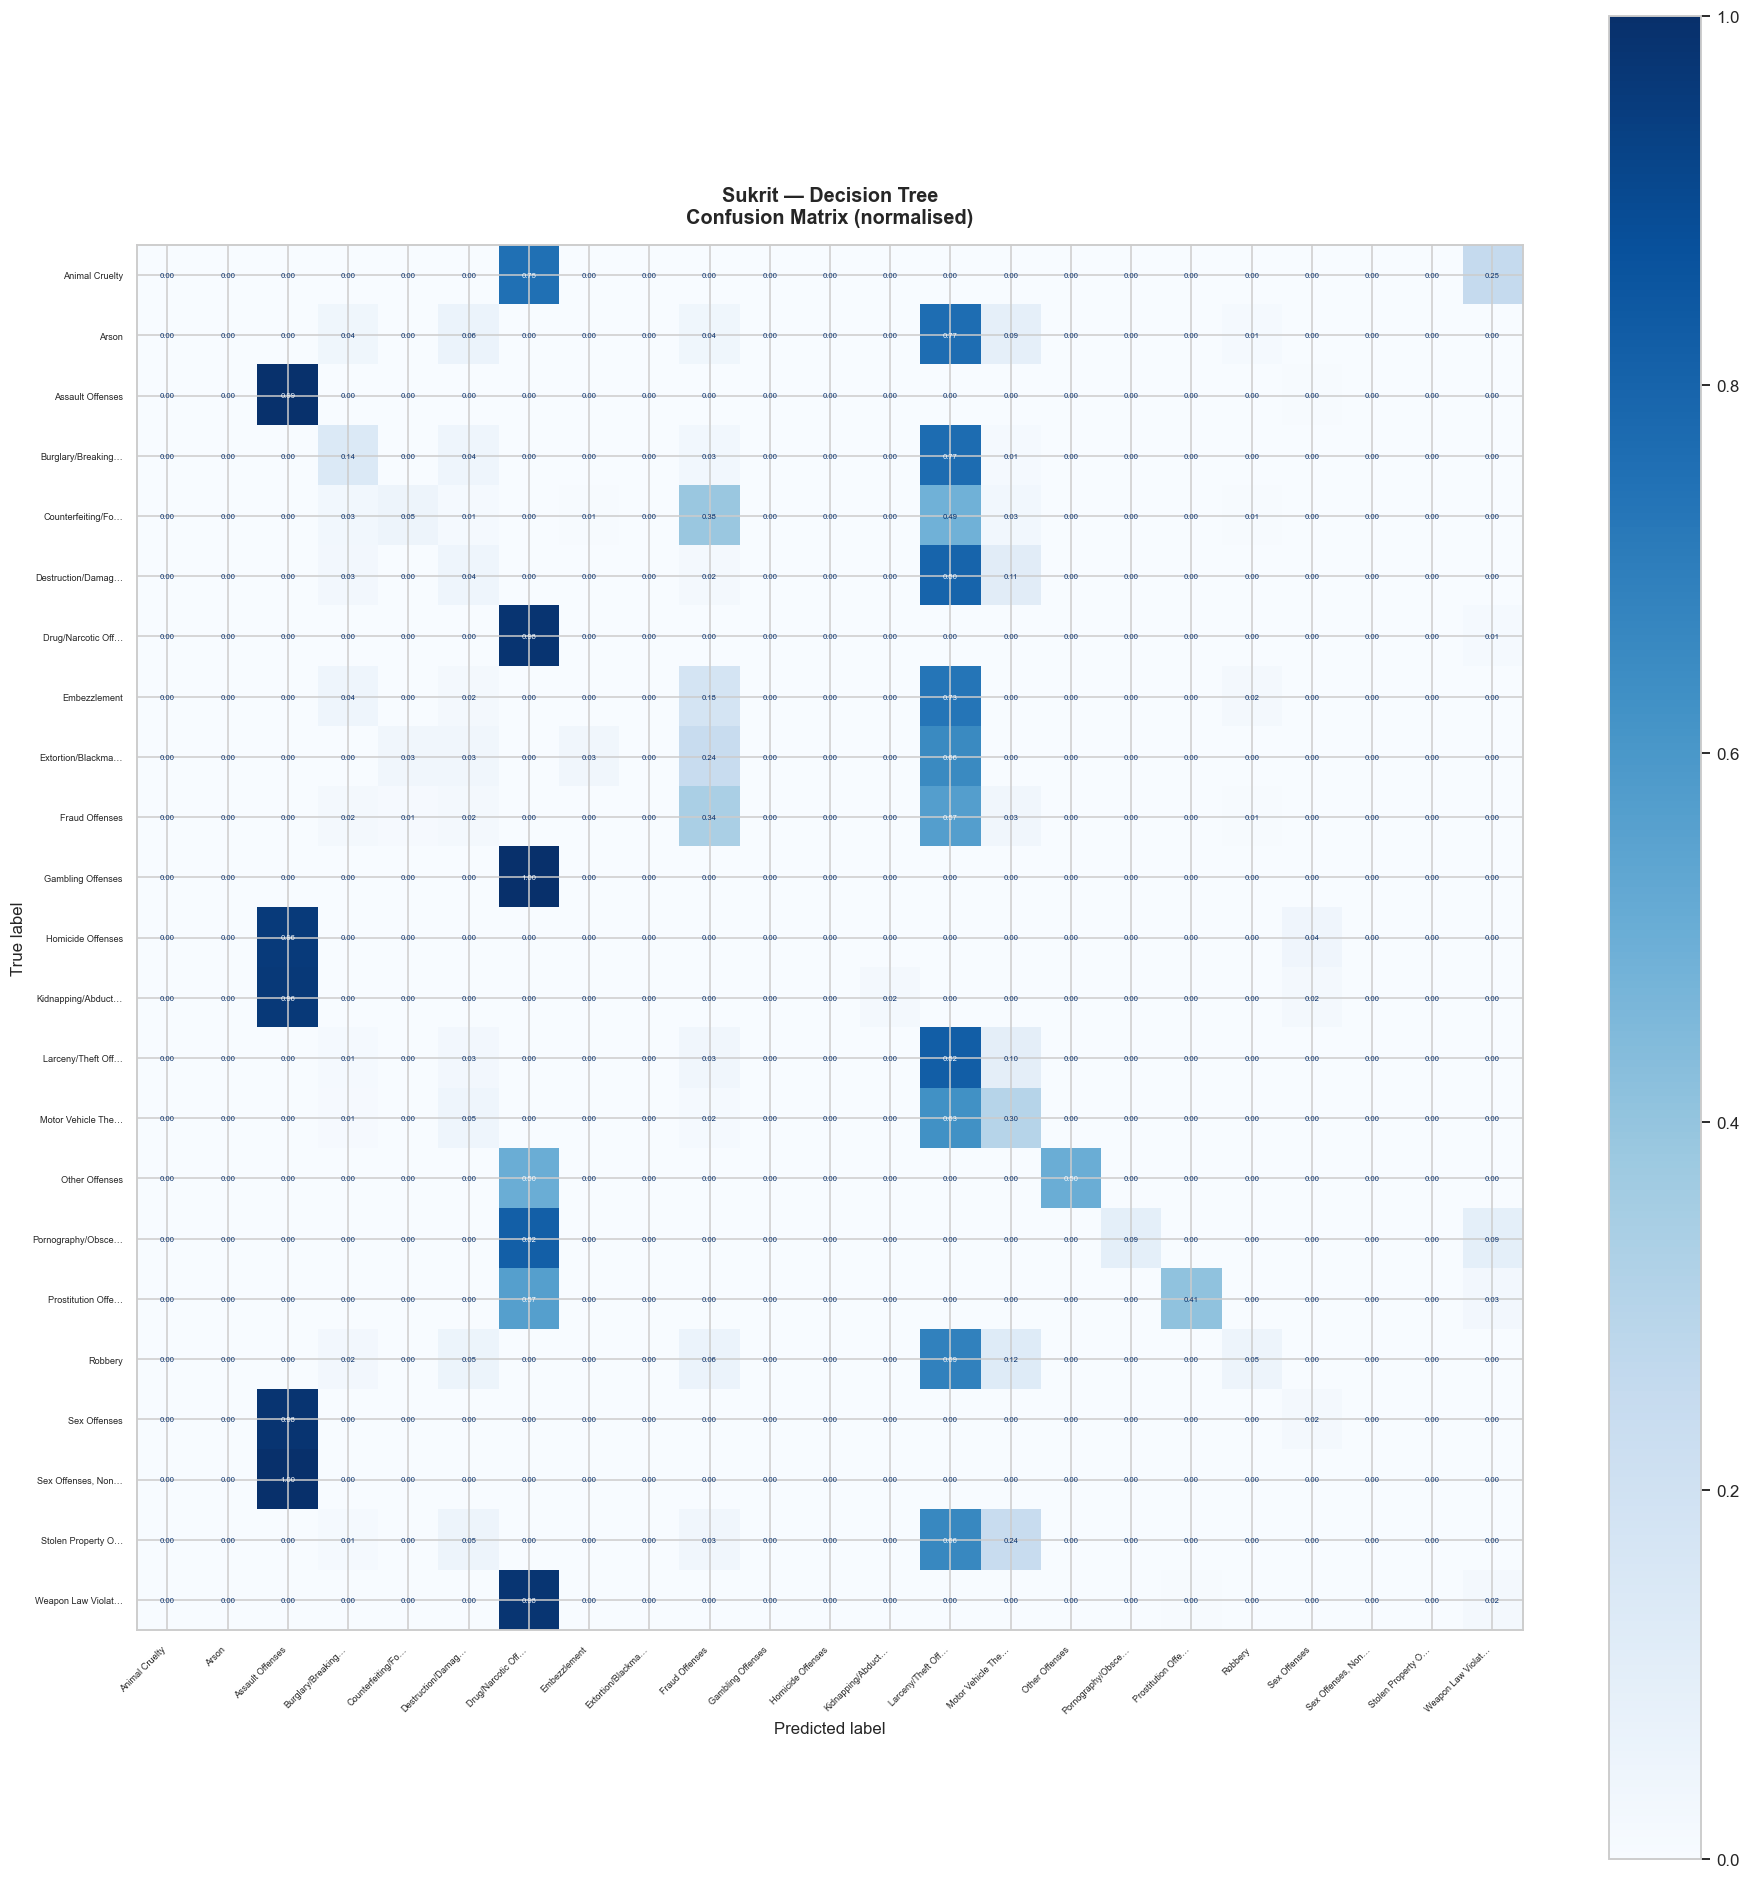


  Sukrit — Random Forest
  Accuracy : 0.6286   Macro F1 : 0.1940   ROC-AUC : nan
                                          precision    recall  f1-score   support

                          Animal Cruelty     0.0000    0.0000    0.0000         8
                                   Arson     0.0000    0.0000    0.0000        81
                        Assault Offenses     0.9139    0.9994    0.9548      5394
            Burglary/Breaking & Entering     0.5217    0.1693    0.2556      1418
                  Counterfeiting/Forgery     0.4091    0.0533    0.0942       169
Destruction/Damage/Vandalism of Property     0.2778    0.0304    0.0548      2963
                  Drug/Narcotic Offenses     0.8530    0.9884    0.9157      4380
                            Embezzlement     0.0000    0.0000    0.0000        45
                     Extortion/Blackmail     0.0000    0.0000    0.0000        29
                          Fraud Offenses     0.5947    0.3274    0.4223      1573
               

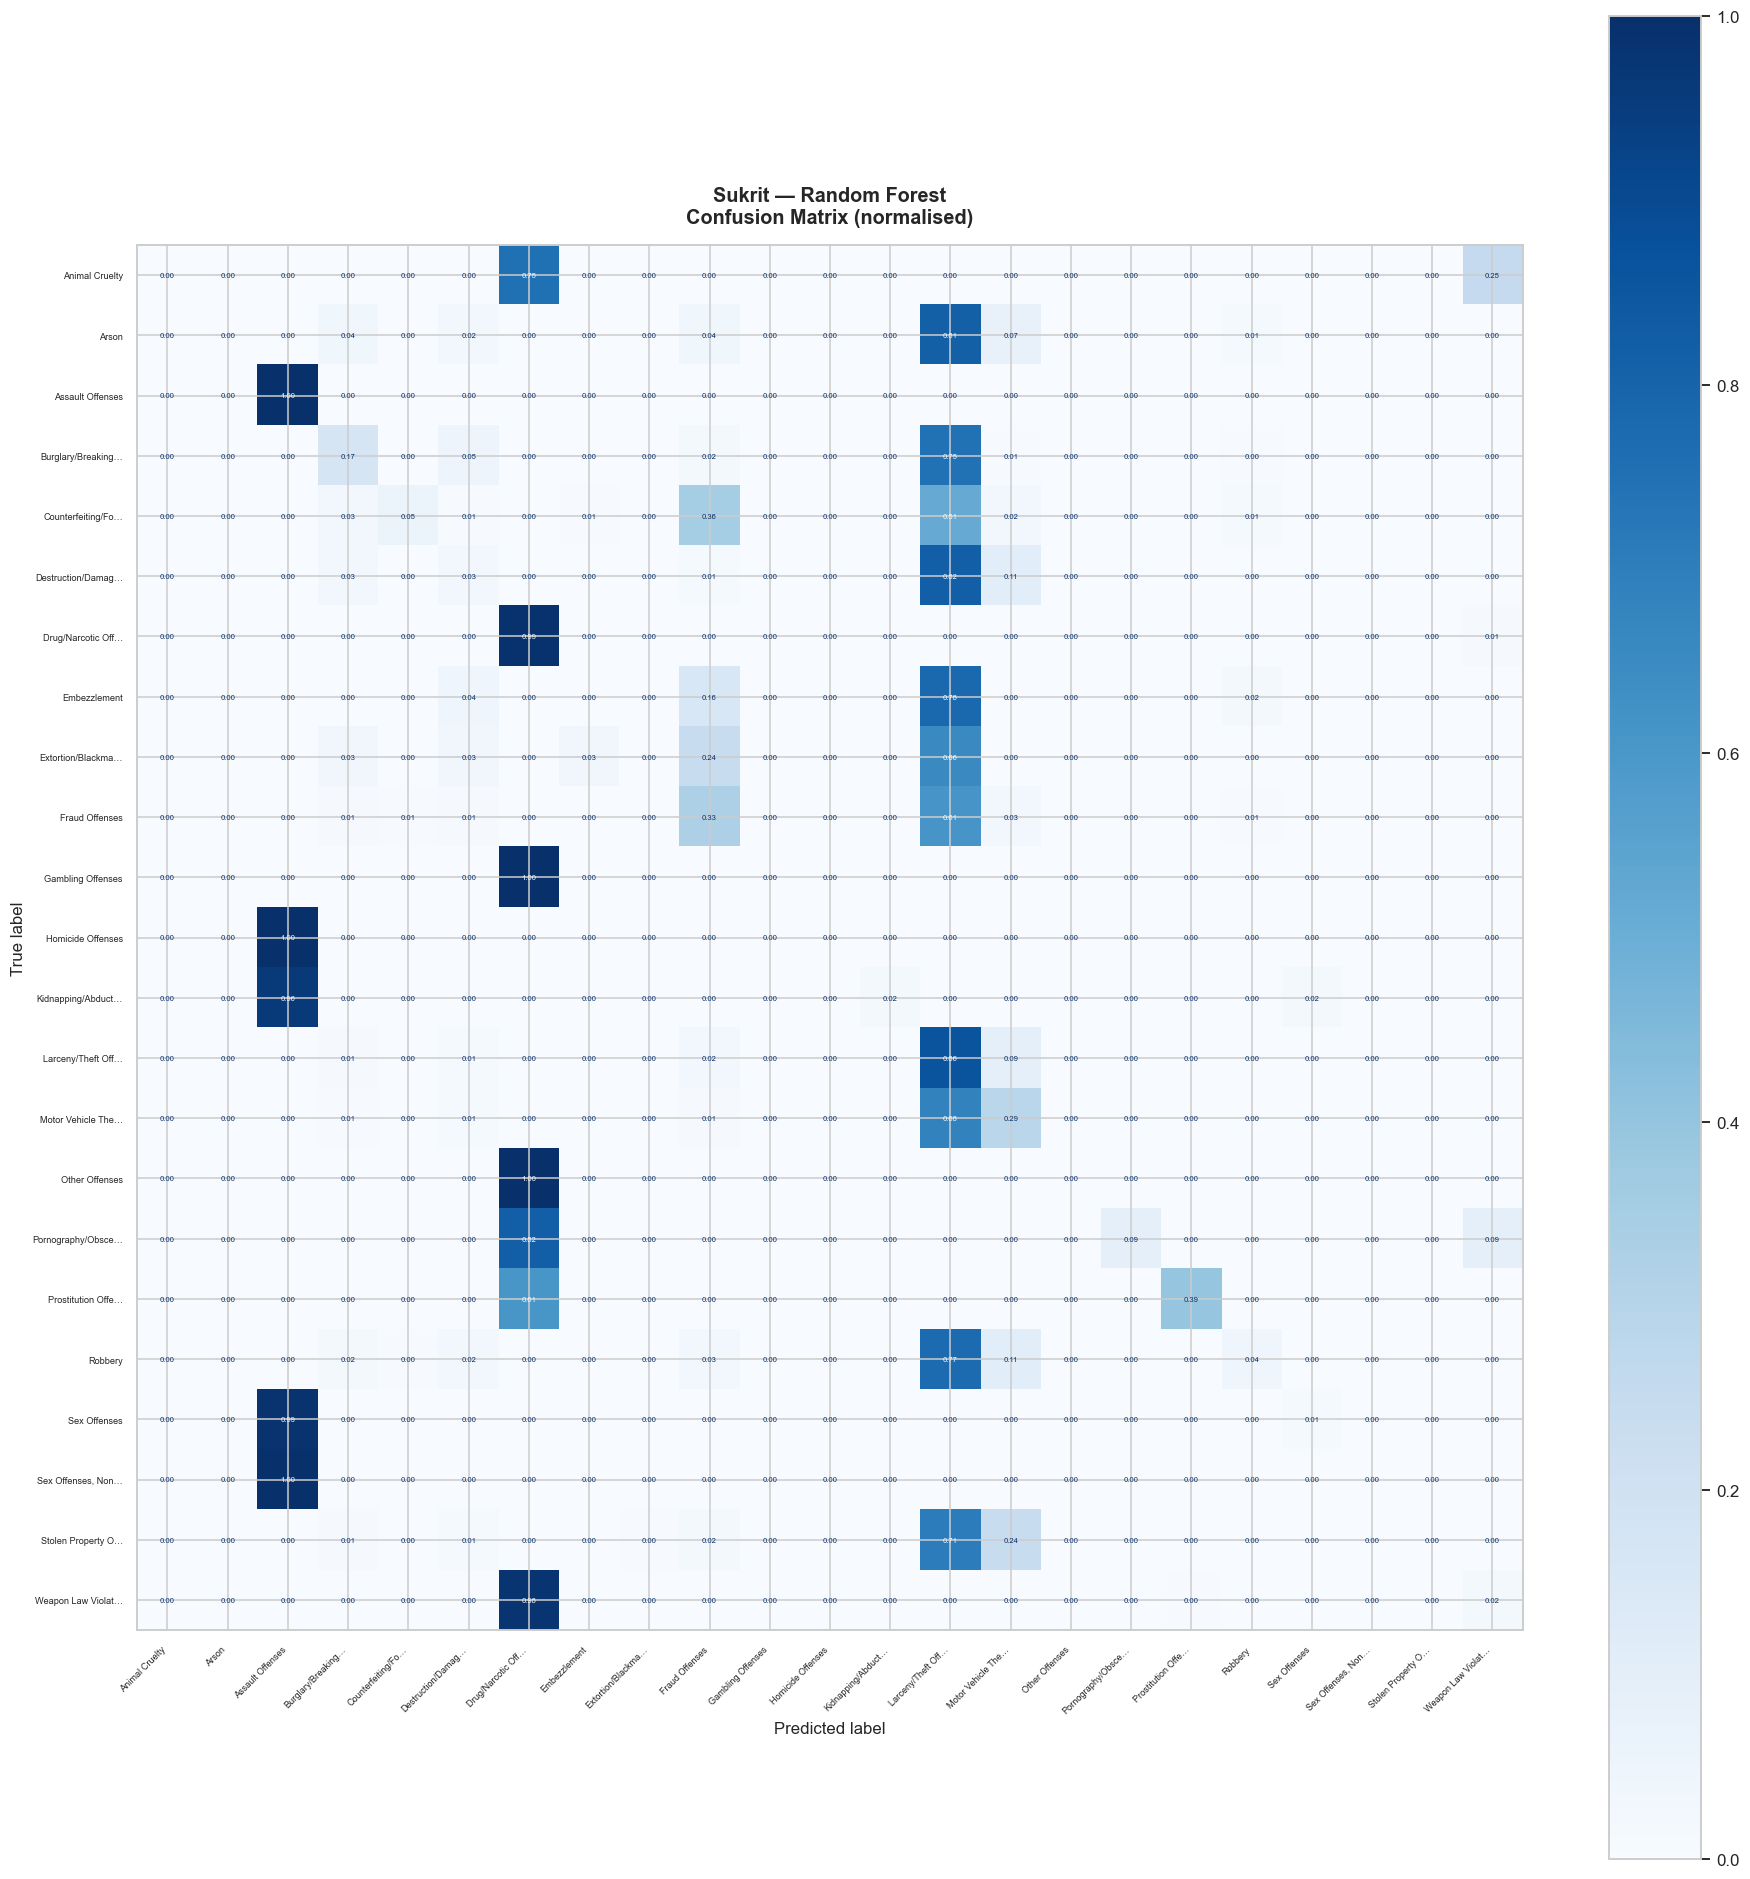


  Sukrit — Gradient Boosting
  Accuracy : 0.6223   Macro F1 : 0.1620   ROC-AUC : nan
                                          precision    recall  f1-score   support

                          Animal Cruelty     0.0000    0.0000    0.0000         8
                                   Arson     0.0000    0.0000    0.0000        81
                        Assault Offenses     0.9157    0.9802    0.9468      5394
            Burglary/Breaking & Entering     0.5227    0.2031    0.2925      1418
                  Counterfeiting/Forgery     0.2500    0.0059    0.0116       169
Destruction/Damage/Vandalism of Property     0.4461    0.0307    0.0575      2963
                  Drug/Narcotic Offenses     0.8530    0.9630    0.9047      4380
                            Embezzlement     0.0000    0.0000    0.0000        45
                     Extortion/Blackmail     0.0000    0.0000    0.0000        29
                          Fraud Offenses     0.5485    0.3344    0.4155      1573
           

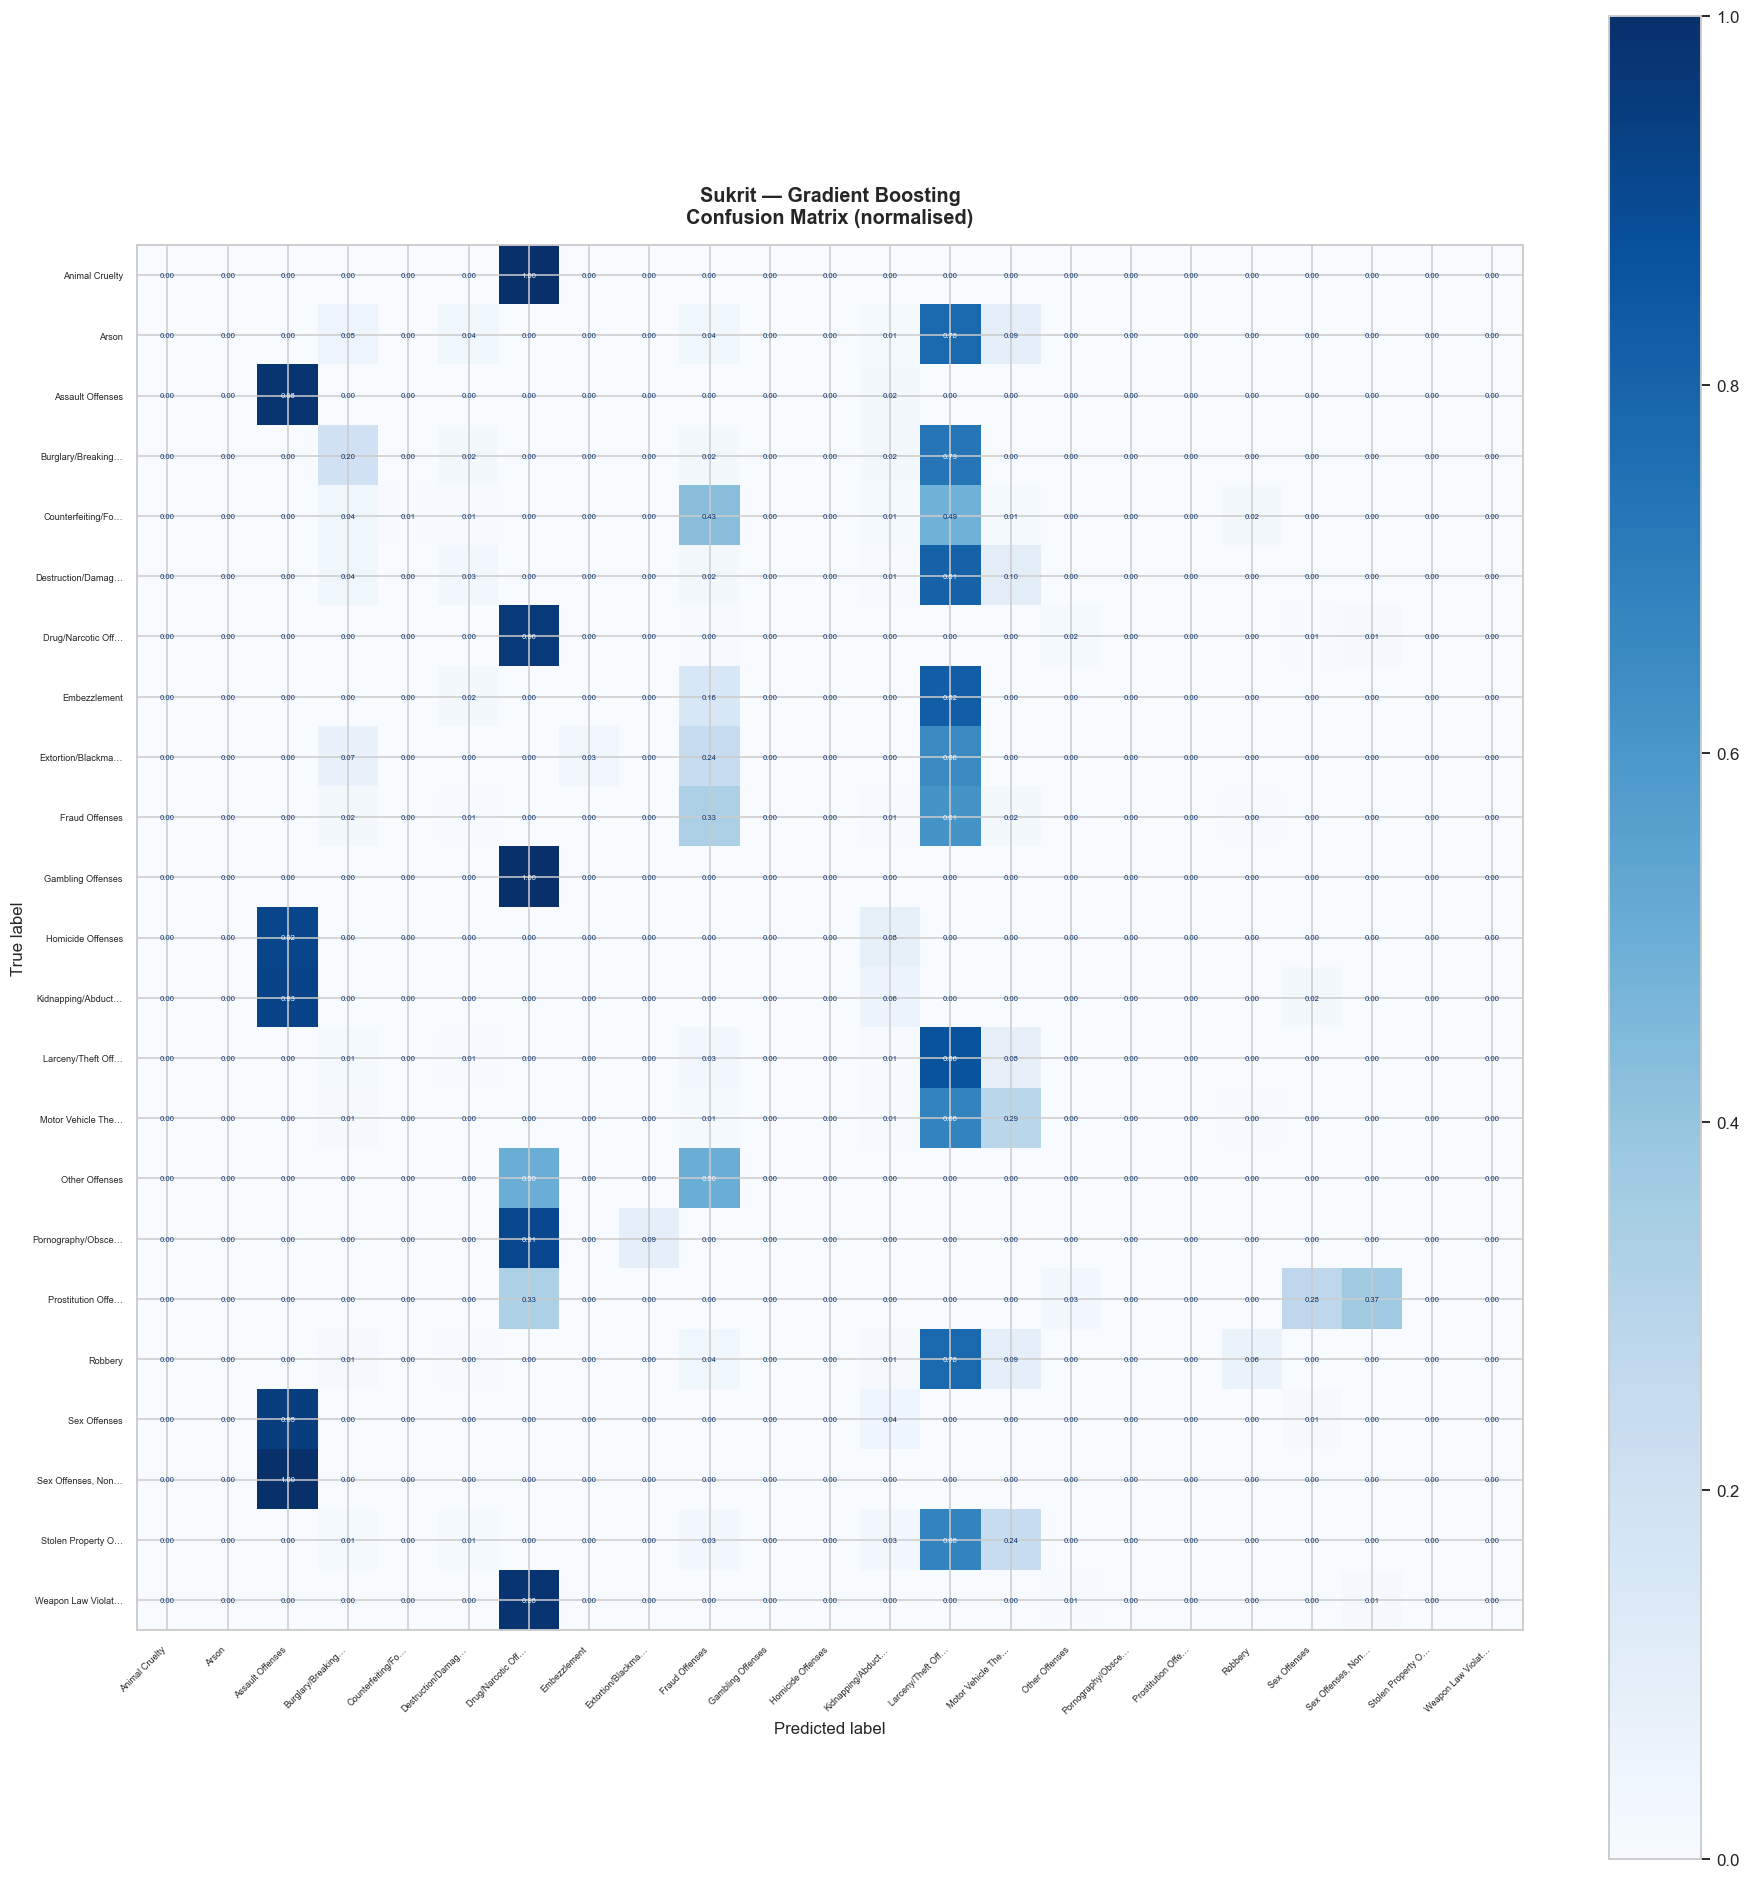

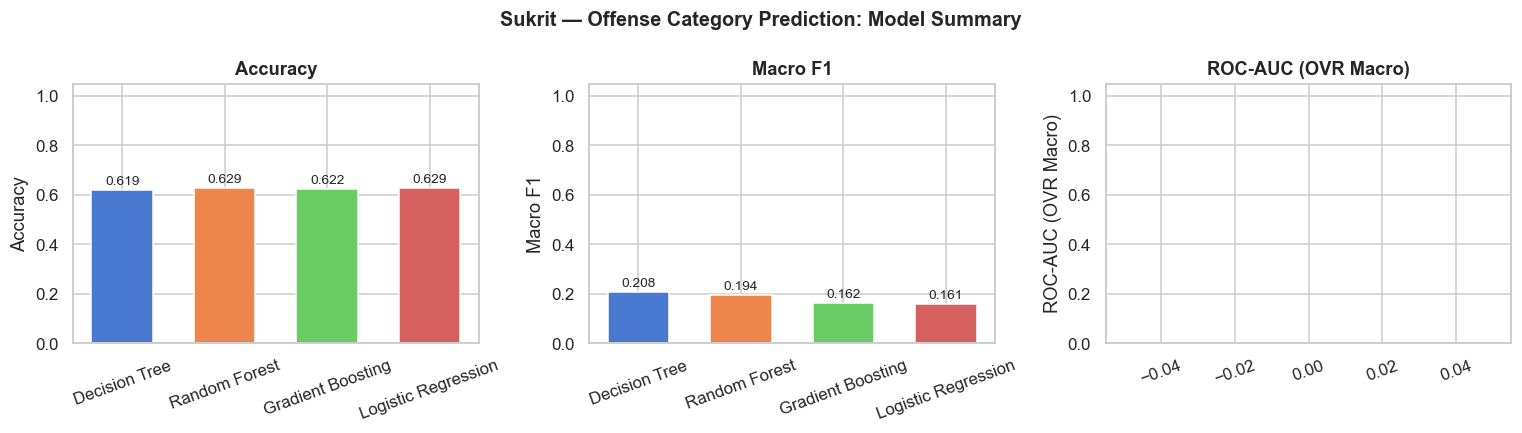

In [13]:
SUK_FEATURES = ['crime_against', 'state', 'month_num_num',
                'incident_hour_num', 'location_name', 'attempt_complete_flag']
SUK_TARGET   = 'offense_category_name'

suk_df = offense_view[SUK_FEATURES + [SUK_TARGET]].dropna().copy()
suk_sample = sample_for_models(suk_df, MAX_ROWS, RANDOM_STATE)
print(f"Sukrit model rows: {len(suk_sample):,}")

X_s = pd.get_dummies(suk_sample.drop(columns=[SUK_TARGET]), drop_first=True)
y_s = suk_sample[SUK_TARGET].astype(str)

X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(
    X_s, y_s, test_size=TEST_SIZE, stratify=y_s, random_state=RANDOM_STATE
)

suk_classes       = np.array(sorted(y_s_test.unique()))
n_classes_s       = len(suk_classes)

def shorten_label(name, maxlen=18):
    return name if len(name) <= maxlen else name[:maxlen - 1] + "…"

suk_classes_short = np.array([shorten_label(c) for c in suk_classes])

suk_models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'Decision Tree':       DecisionTreeClassifier(max_depth=20, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=20,
                                                   n_jobs=-1, random_state=RANDOM_STATE),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150,
                                                       random_state=RANDOM_STATE),
}

suk_results_rows = []
suk_fitted       = {}

for name, mdl in suk_models.items():
    mdl.fit(X_s_train, y_s_train)
    pred = mdl.predict(X_s_test)
    acc  = accuracy_score(y_s_test, pred)
    f1m  = f1_score(y_s_test, pred, average='macro')

    # ROC-AUC (scalar only — no curves plotted for Sukrit)
    if hasattr(mdl, 'predict_proba'):
        proba_s = mdl.predict_proba(X_s_test)
        try:
            auc_val = roc_auc_score(y_s_test, proba_s,
                                    multi_class='ovr', average='macro')
        except Exception:
            auc_val = float('nan')
    else:
        auc_val = float('nan')

    suk_results_rows.append({'model': name, 'contributor': 'Sukrit',
                              'accuracy': acc, 'macro_f1': f1m, 'roc_auc': auc_val})
    suk_fitted[name] = mdl

    print(f'\n{"="*60}')
    print(f'  Sukrit — {name}')
    print(f'{"="*60}')
    print(f'  Accuracy : {acc:.4f}   Macro F1 : {f1m:.4f}   ROC-AUC : {auc_val:.4f}')
    print(classification_report(y_s_test, pred, digits=4))

    # ── Confusion matrix (standalone figure, labels never overlap) ─────────
    cm_inch = max(10, n_classes_s * 0.75)
    fig_cm, ax_cm = plt.subplots(figsize=(cm_inch, cm_inch))

    ConfusionMatrixDisplay.from_predictions(
        y_s_test, pred,
        normalize='true',
        cmap='Blues',
        ax=ax_cm,
        display_labels=suk_classes_short,
        colorbar=True,
        values_format='.2f',
        text_kw={'fontsize': max(5, 9 - n_classes_s // 4)},
    )
    tick_fs = max(6, 10 - n_classes_s // 4)
    ax_cm.set_xticklabels(suk_classes_short, rotation=45, ha='right', fontsize=tick_fs)
    ax_cm.set_yticklabels(suk_classes_short, rotation=0,  fontsize=tick_fs)
    ax_cm.set_title(f'Sukrit — {name}\nConfusion Matrix (normalised)',
                    fontweight='bold', fontsize=13, pad=14)
    ax_cm.set_xlabel('Predicted label', fontsize=11)
    ax_cm.set_ylabel('True label',      fontsize=11)
    fig_cm.tight_layout()
    fig_cm.savefig(OUTPUT_DIR / f'sukrit_cm_{name.replace(" ","_").lower()}.png',
                   dpi=150, bbox_inches='tight')
    plt.show()

# ── Summary comparison bar chart ──────────────────────────────────────────
suk_df_res = pd.DataFrame(suk_results_rows).sort_values('macro_f1', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
palette_s  = sns.color_palette('muted', len(suk_df_res))

for ax, col, label in zip(axes,
                           ['accuracy', 'macro_f1', 'roc_auc'],
                           ['Accuracy', 'Macro F1', 'ROC-AUC (OVR Macro)']):
    sub  = suk_df_res.dropna(subset=[col])
    bars = ax.bar(sub['model'], sub[col], color=palette_s[:len(sub)],
                  edgecolor='white', width=0.6)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel(label)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, sub[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Sukrit — Offense Category Prediction: Model Summary',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sukrit_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Edison — Arrest Prediction

**Task:** Binary classification — did this incident result in an arrest?  
**Key metric:** ROC-AUC (arrests are a minority class)


Edison rows  : 250,000
Arrest rate  : 29.87%
Train: 200,000  Test: 50,000
  Training Logistic Regression... done. AUC=0.6732

  Edison — Logistic Regression
  Accuracy: 0.6391  Macro F1: 0.5824  ROC-AUC: 0.6732
              precision    recall  f1-score   support

Not Arrested     0.7551    0.7184    0.7363     35064
    Arrested     0.4066    0.4530    0.4286     14936

    accuracy                         0.6391     50000
   macro avg     0.5809    0.5857    0.5824     50000
weighted avg     0.6510    0.6391    0.6444     50000



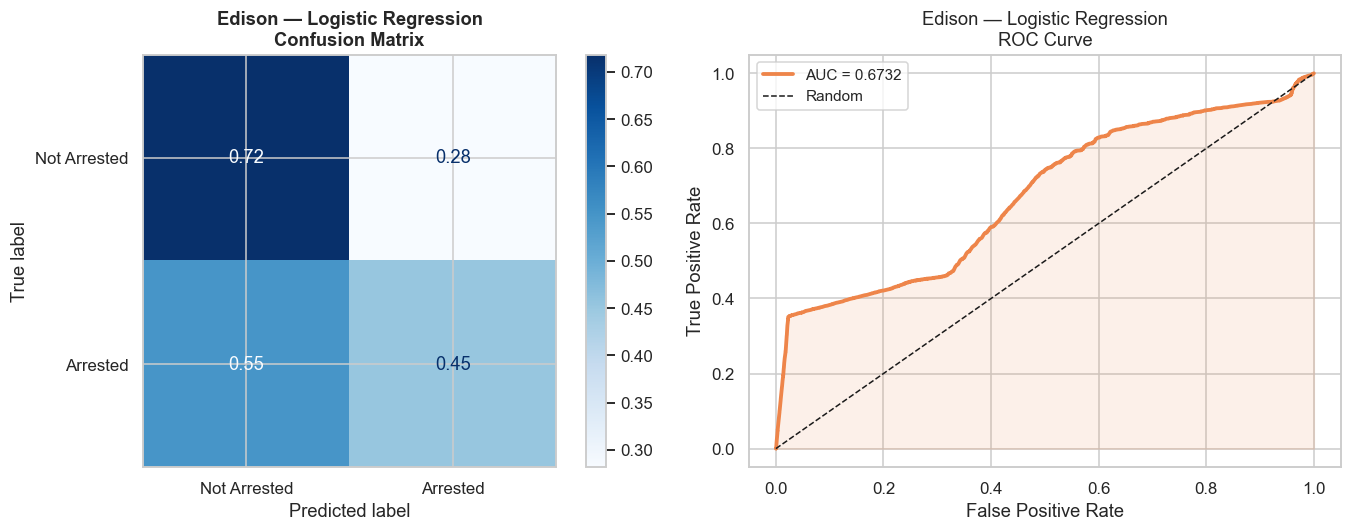

  Training Random Forest... done. AUC=0.8543

  Edison — Random Forest
  Accuracy: 0.8120  Macro F1: 0.7476  ROC-AUC: 0.8543
              precision    recall  f1-score   support

Not Arrested     0.8193    0.9391    0.8751     35064
    Arrested     0.7821    0.5137    0.6201     14936

    accuracy                         0.8120     50000
   macro avg     0.8007    0.7264    0.7476     50000
weighted avg     0.8082    0.8120    0.7989     50000



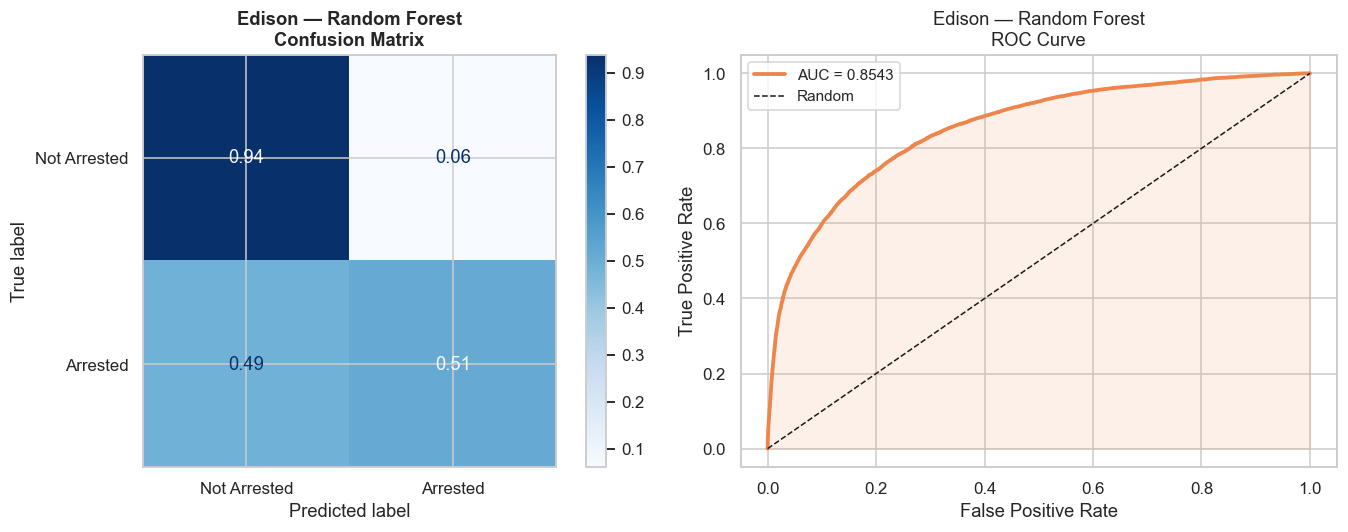

  Training Hist Gradient Boosting... done. AUC=0.8588

  Edison — Hist Gradient Boosting
  Accuracy: 0.7739  Macro F1: 0.7506  ROC-AUC: 0.8588
              precision    recall  f1-score   support

Not Arrested     0.8931    0.7697    0.8268     35064
    Arrested     0.5917    0.7837    0.6743     14936

    accuracy                         0.7739     50000
   macro avg     0.7424    0.7767    0.7506     50000
weighted avg     0.8031    0.7739    0.7812     50000



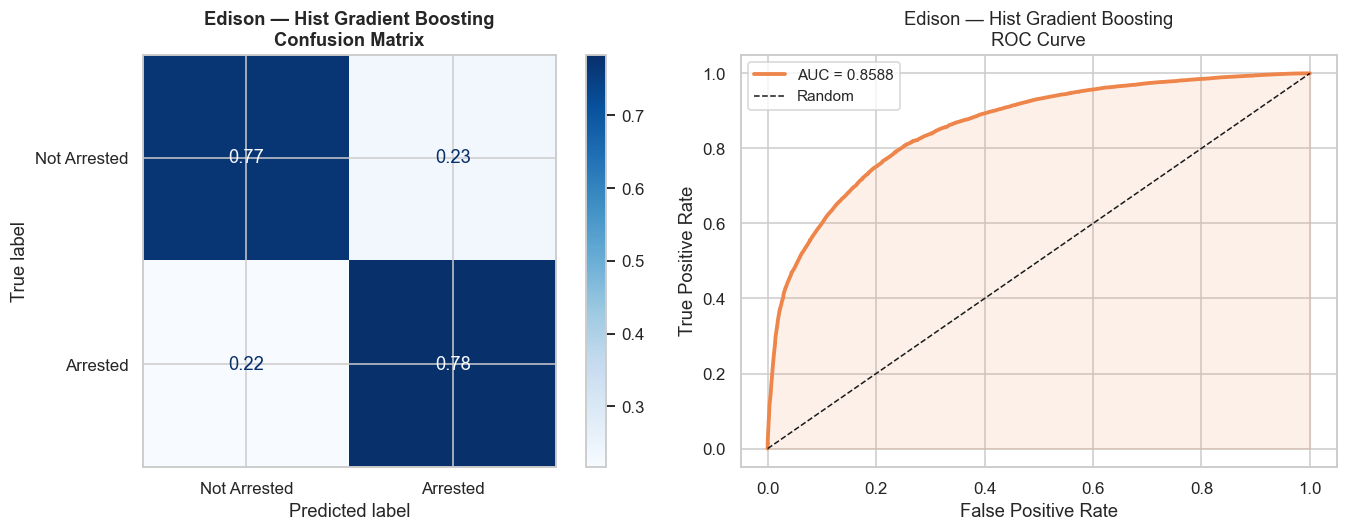

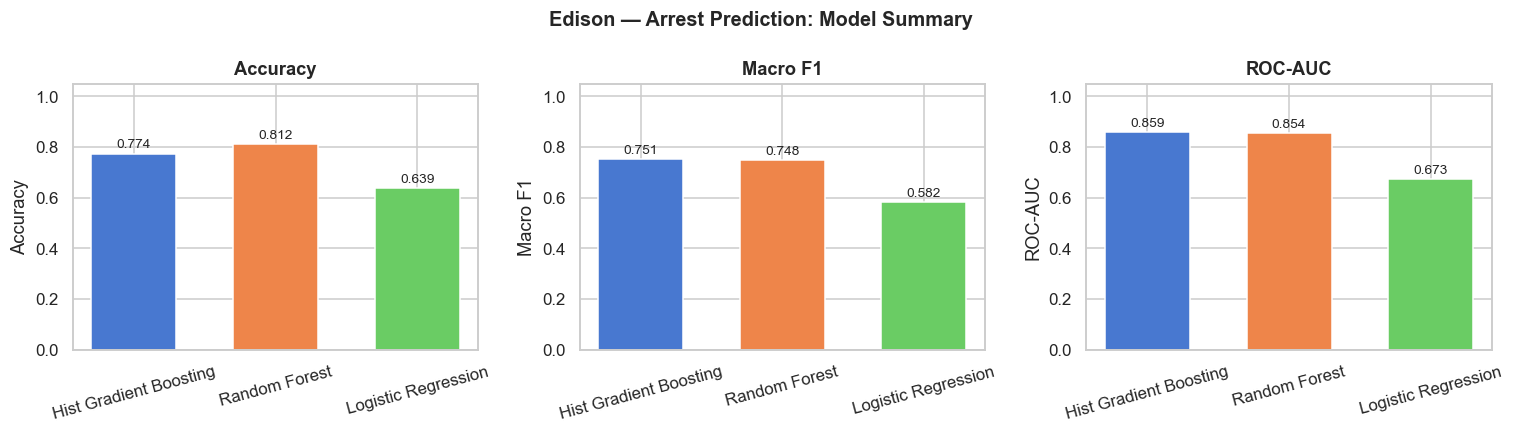

In [14]:
# ── Edison — Arrest Prediction ───────────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier  # fast, handles NaN natively

ED_FEATURES = ['offense_category_name', 'crime_against',
                'location_name', 'attempt_complete_flag',
                'incident_hour_num', 'month_num_num']

# ── Build arrest flag ──────────────────────────────────────────────────────
df_arrestee = load_fact_table(state_year_dirs, FACT_FILES['arrestee'])
arrested_ids = set(zip(
    df_arrestee['incident_id'].astype(str),
    df_arrestee['state'].astype(str),
    df_arrestee['year'].astype(str),
))

ed_df = offense_view[
    ['incident_id', 'state', 'year'] + ED_FEATURES
].dropna(subset=['offense_category_name', 'crime_against']).copy()

ed_df['arrested'] = [
    1 if (str(r.incident_id), str(r.state), str(r.year)) in arrested_ids else 0
    for r in ed_df.itertuples()
]

ed_sample = sample_for_models(ed_df, MAX_ROWS, RANDOM_STATE)
print(f"Edison rows  : {len(ed_sample):,}")
print(f"Arrest rate  : {ed_sample['arrested'].mean():.2%}")

# ── Encode categoricals, coerce numerics ──────────────────────────────────
X_e = ed_sample[ED_FEATURES].copy()
y_e = ed_sample['arrested'].astype(int).values

for col in ['offense_category_name', 'crime_against',
             'location_name', 'attempt_complete_flag']:
    X_e[col] = LabelEncoder().fit_transform(X_e[col].fillna('MISSING').astype(str))
for col in ['incident_hour_num', 'month_num_num']:
    X_e[col] = pd.to_numeric(X_e[col], errors='coerce')

X_e_arr = X_e[ED_FEATURES].values.astype(float)

X_e_train, X_e_test, y_e_train, y_e_test = train_test_split(
    X_e_arr, y_e, test_size=TEST_SIZE, stratify=y_e, random_state=RANDOM_STATE
)
print(f"Train: {X_e_train.shape[0]:,}  Test: {X_e_test.shape[0]:,}")

# ── Models — HistGradientBoosting replaces GradientBoosting (10-50x faster) ─
# LogisticRegression and RandomForest wrapped in Pipeline with imputer+scaler.
# HistGradientBoostingClassifier handles NaN natively — no imputer needed.
def _pipe(est):
    return Pipeline([
        ('imp',   SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('model', est),
    ])

ed_models = {
    'Logistic Regression':     _pipe(LogisticRegression(
                                   max_iter=500, class_weight='balanced',
                                   random_state=RANDOM_STATE, solver='saga')),
    'Random Forest':           _pipe(RandomForestClassifier(
                                   n_estimators=100, max_depth=10,
                                   n_jobs=-1, random_state=RANDOM_STATE)),
    'Hist Gradient Boosting':  HistGradientBoostingClassifier(
                                   max_iter=100, max_depth=6,
                                   random_state=RANDOM_STATE,
                                   class_weight='balanced'),
}

ed_results_rows = []

for name, pipe in ed_models.items():
    print(f"  Training {name}...", end=" ", flush=True)
    pipe.fit(X_e_train, y_e_train)
    proba = pipe.predict_proba(X_e_test)[:, 1]
    preds = pipe.predict(X_e_test)
    auc_e = roc_auc_score(y_e_test, proba)
    acc_e = accuracy_score(y_e_test, preds)
    f1_e  = f1_score(y_e_test, preds, average='macro')
    print(f"done. AUC={auc_e:.4f}")

    ed_results_rows.append({'model': name, 'contributor': 'Edison',
                             'accuracy': acc_e, 'macro_f1': f1_e, 'roc_auc': auc_e})

    print(f'\n{"="*60}\n  Edison — {name}\n{"="*60}')
    print(f'  Accuracy: {acc_e:.4f}  Macro F1: {f1_e:.4f}  ROC-AUC: {auc_e:.4f}')
    print(classification_report(y_e_test, preds,
                                  target_names=['Not Arrested', 'Arrested'], digits=4))

    fpr, tpr, _ = roc_curve(y_e_test, proba)
    color_e = sns.color_palette('muted')[1]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_e_test, preds, normalize='true', cmap='Blues', ax=axes[0],
        display_labels=['Not Arrested', 'Arrested'], colorbar=True, values_format='.2f')
    axes[0].set_title(f'Edison — {name}\nConfusion Matrix', fontweight='bold')
    axes[1].plot(fpr, tpr, lw=2.5, color=color_e, label=f'AUC = {auc_e:.4f}')
    axes[1].fill_between(fpr, tpr, alpha=0.12, color=color_e)
    axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random')
    axes[1].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
                title=f'Edison — {name}\nROC Curve')
    axes[1].legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'edison_{name.replace(" ","_").lower()}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

ed_df_res = pd.DataFrame(ed_results_rows).sort_values('roc_auc', ascending=False)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
palette_e  = sns.color_palette('muted', len(ed_df_res))
for ax, col, label in zip(axes, ['accuracy','macro_f1','roc_auc'],
                           ['Accuracy','Macro F1','ROC-AUC']):
    bars = ax.bar(ed_df_res['model'], ed_df_res[col],
                  color=palette_e, edgecolor='white', width=0.6)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel(label)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, ed_df_res[col]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('Edison — Arrest Prediction: Model Summary',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'edison_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Khue — Monthly Forecasting & Prescriptive Patrol Allocation

**Task:** Forecast monthly crime counts per state for 2024 using Ridge regression  
with temporal lag features, then optimise patrol unit allocation via linear programming.


Monthly records : 192
Years           : [2021, 2022, 2023, 2024]
States          : ['CA', 'ID', 'MA', 'NJ']
After lag features: 180 records
Train: 132  Test: 48  Test year: 2024

MAE=1685.4  RMSE=2735.4  R²=0.9947


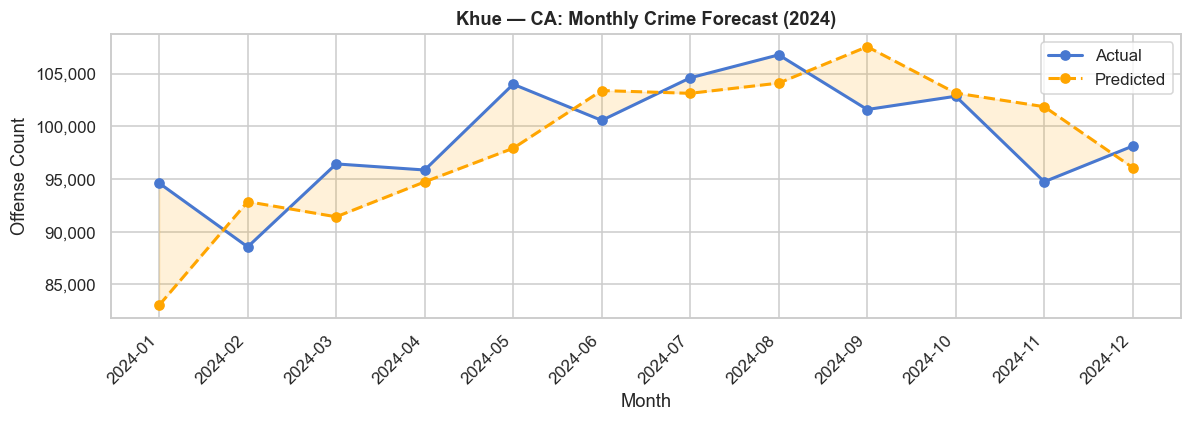

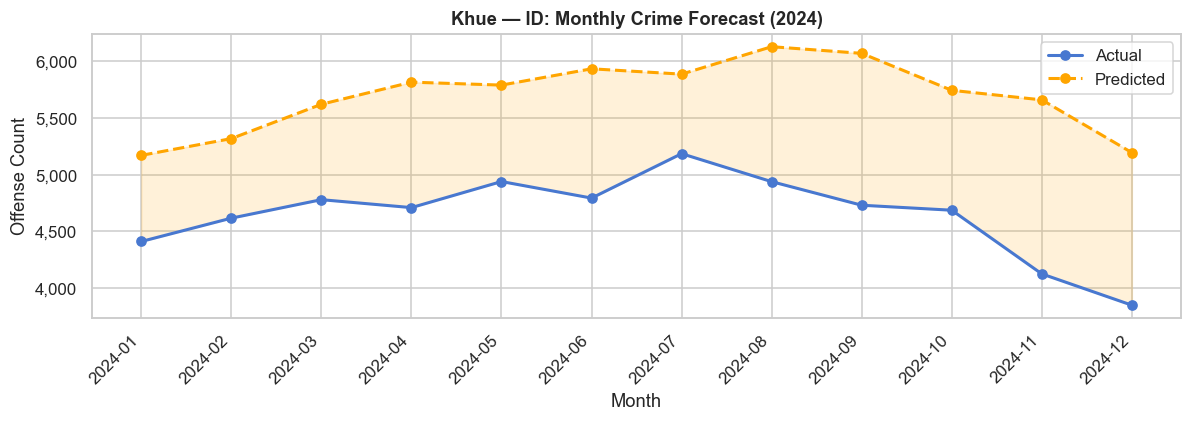

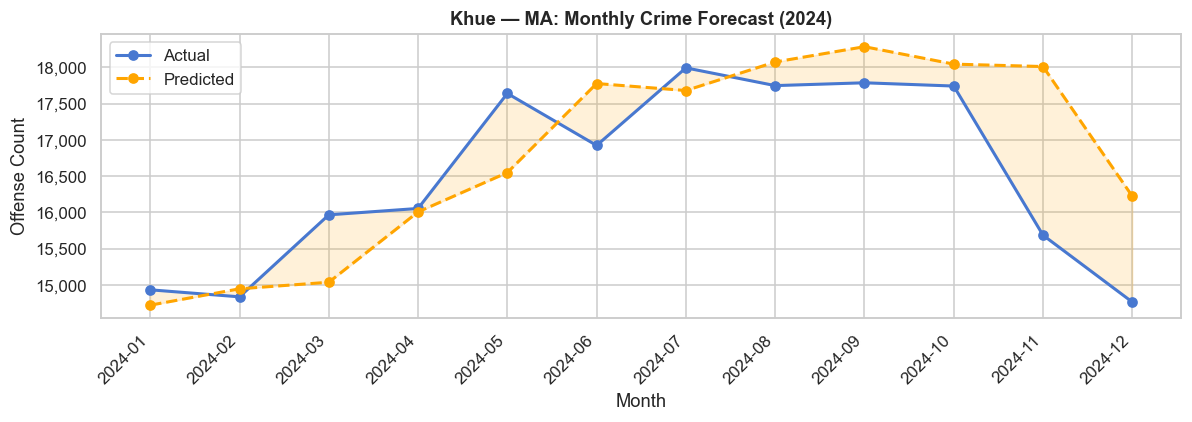

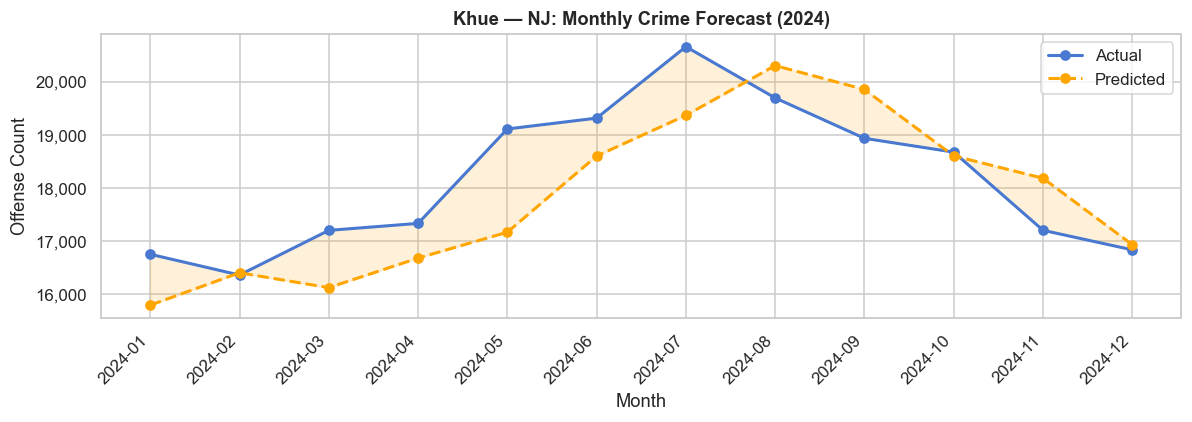


── Patrol Allocation ─────────────────────────────────
crime_against   count  allocated_units
     Property 3411607               98
       Person 1234503                1
      Society  826285                1


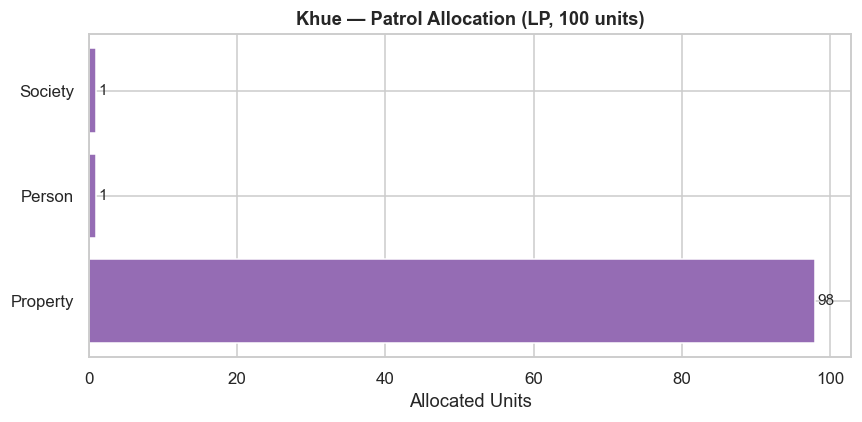

In [15]:
# ── Khue — Monthly Forecasting & Prescriptive Patrol Allocation ──────────
# Uses monthly_incidents built during data loading (cell 4).
# No re-reading of files needed here.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

try:
    from scipy.optimize import linprog
    _SCIPY = True
except ImportError:
    _SCIPY = False

monthly = monthly_incidents.copy()
print(f"Monthly records : {len(monthly):,}")
print(f"Years           : {sorted(monthly['yr'].unique())}")
print(f"States          : {sorted(monthly['state'].unique())}")

# ── Lag and rolling features ──────────────────────────────────────────────
for lag in [1, 2, 3]:
    monthly[f'lag_{lag}'] = monthly.groupby('state')['crime_count'].shift(lag)
for w in [3, 6]:
    monthly[f'roll_{w}'] = (
        monthly.groupby('state')['crime_count']
        .transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean())
    )
FEAT = ['lag_1', 'lag_2', 'lag_3', 'roll_3', 'roll_6', 'state_enc']
monthly = monthly.dropna(subset=['lag_1', 'lag_2', 'lag_3', 'roll_3', 'roll_6'])
print(f"After lag features: {len(monthly):,} records")

# ── Train / test split ────────────────────────────────────────────────────
test_yr = int(monthly['yr'].max())
train_m = monthly[monthly['yr'] < test_yr].copy()
test_m  = monthly[monthly['yr'] == test_yr].copy()
print(f"Train: {len(train_m):,}  Test: {len(test_m):,}  Test year: {test_yr}")

# ── Ridge regression ──────────────────────────────────────────────────────
le = LabelEncoder()
le.fit(monthly['state'].astype(str))
train_m['state_enc'] = le.transform(train_m['state'].astype(str))
test_m['state_enc']  = le.transform(test_m['state'].astype(str))

imp = SimpleImputer(strategy='median')
X_tr = imp.fit_transform(train_m[FEAT])
X_te = imp.transform(test_m[FEAT])

ridge = Ridge(alpha=1.0)
ridge.fit(X_tr, train_m['crime_count'])
test_m = test_m.copy()
test_m['predicted'] = ridge.predict(X_te)
test_m['residual']  = test_m['crime_count'] - test_m['predicted']

mae  = test_m['residual'].abs().mean()
rmse = (test_m['residual'] ** 2).mean() ** 0.5
sst  = ((test_m['crime_count'] - test_m['crime_count'].mean()) ** 2).sum()
r2   = 1 - (test_m['residual'] ** 2).sum() / sst if sst > 0 else float('nan')
print(f"\nMAE={mae:.1f}  RMSE={rmse:.1f}  R²={r2:.4f}")

# ── Per-state forecast plots ───────────────────────────────────────────────
_odir = Path('model_outputs')
_odir.mkdir(exist_ok=True)

for state, grp in test_m.groupby('state'):
    grp = grp.sort_values(['yr','mon']).copy()
    grp['period'] = grp['yr'].astype(str)+'-'+grp['mon'].astype(str).str.zfill(2)
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(range(len(grp)), grp['crime_count'], marker='o', lw=2, label='Actual')
    ax.plot(range(len(grp)), grp['predicted'],   marker='o', lw=2,
            ls='--', color='orange', label='Predicted')
    ax.fill_between(range(len(grp)),
                    grp['predicted'].clip(lower=0), grp['crime_count'],
                    alpha=0.15, color='orange')
    ax.set_title(f'Khue — {state}: Monthly Crime Forecast ({test_yr})', fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Offense Count')
    ax.set_xticks(range(len(grp)))
    ax.set_xticklabels(grp['period'], rotation=45, ha='right')
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.savefig(_odir / f'khue_forecast_{state}.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── Patrol allocation ─────────────────────────────────────────────────────
if _SCIPY:
    _ca = (offense_view.dropna(subset=['crime_against'])
           .groupby('crime_against').size()
           .reset_index(name='count')
           .sort_values('count', ascending=False)
           .reset_index(drop=True))

    if len(_ca) > 0:
        n = len(_ca); TOTAL = 100
        w = _ca['count'].values.astype(float)
        res = linprog(-w/w.sum(), A_ub=[np.ones(n)], b_ub=[float(TOTAL)],
                      bounds=[(1.0, float(TOTAL))]*n, method='highs')
        if res.success:
            _ca['allocated_units'] = np.round(res.x).astype(int)
            print('\n── Patrol Allocation ─────────────────────────────────')
            print(_ca[['crime_against','count','allocated_units']].to_string(index=False))
            fig, ax = plt.subplots(figsize=(8, 4))
            bars = ax.barh(_ca['crime_against'], _ca['allocated_units'],
                           color=sns.color_palette('muted')[4])
            for bar, val in zip(bars, _ca['allocated_units']):
                ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                        str(val), va='center', fontsize=10)
            ax.set_title(f'Khue — Patrol Allocation (LP, {TOTAL} units)', fontweight='bold')
            ax.set_xlabel('Allocated Units')
            plt.tight_layout()
            plt.savefig(_odir/'khue_patrol_allocation.png', dpi=150, bbox_inches='tight')
            plt.show()
        else:
            print(f'LP did not converge: {res.message}')
    else:
        print('No crime_against data — skipping patrol allocation.')
else:
    print('Install scipy: pip install scipy')


## 10. Combined Model Comparison

══════════════════════════════════════════════════════════════════════
  Combined Model Comparison
══════════════════════════════════════════════════════════════════════
contributor                  model  accuracy  macro_f1  roc_auc
     Edison Hist Gradient Boosting  0.773860  0.750555 0.858753
     Edison          Random Forest  0.811980  0.747581 0.854280
     Edison    Logistic Regression  0.639140  0.582438 0.673208
      Neeti          Random Forest  0.643380  0.409928 0.726467
      Neeti          Decision Tree  0.641460  0.415163 0.721537
      Neeti       Ridge Classifier  0.641820  0.359406 0.717771
      Neeti    Logistic Regression  0.640180  0.352716 0.717260
     Sukrit    Logistic Regression  0.629451  0.160542      NaN
     Sukrit          Decision Tree  0.619267  0.208192      NaN
     Sukrit          Random Forest  0.628608  0.193997      NaN
     Sukrit      Gradient Boosting  0.622308  0.162003      NaN


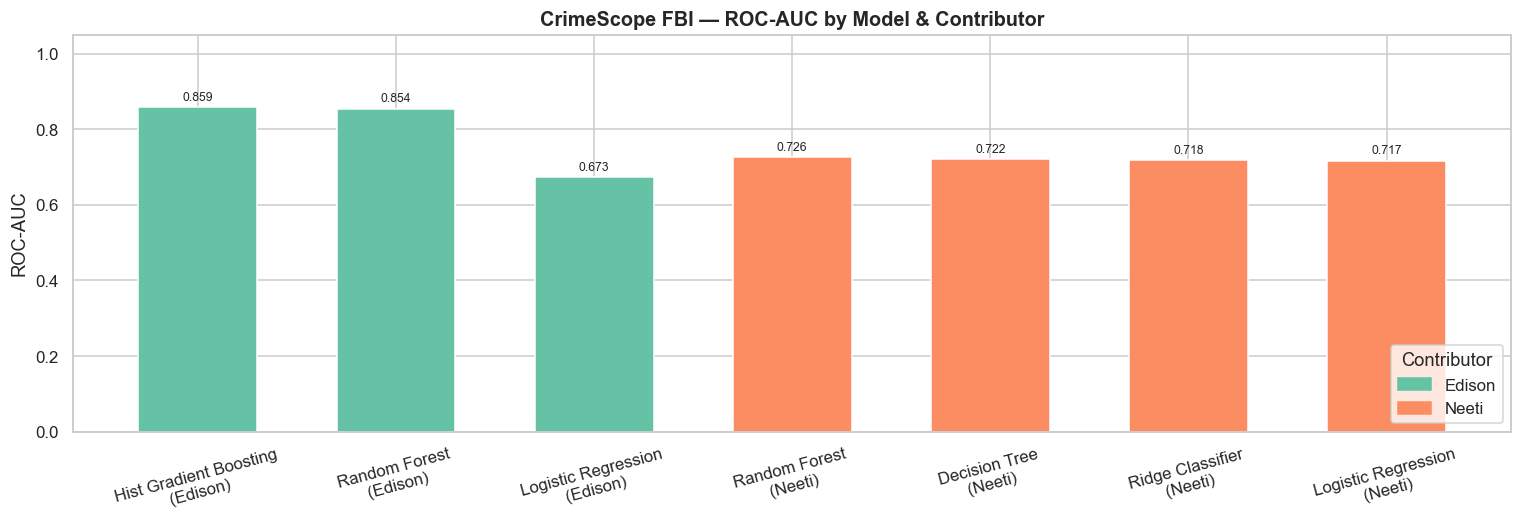

In [16]:
# Merge all contributor result rows into one comparison frame.
all_results = (
    pd.DataFrame(neeti_results + suk_results_rows + ed_results_rows)
    .sort_values(['contributor', 'roc_auc'], ascending=[True, False])
    .reset_index(drop=True)
)

print("═" * 70)
print("  Combined Model Comparison")
print("═" * 70)
print(all_results[['contributor','model','accuracy','macro_f1','roc_auc']].to_string(index=False))

# ── Grouped bar chart — ROC-AUC ────────────────────────────────────────────
has_auc = all_results.dropna(subset=['roc_auc'])
contributor_palette = {c: sns.color_palette('Set2')[i]
                        for i, c in enumerate(has_auc['contributor'].unique())}

fig, ax = plt.subplots(figsize=(14, 5))
labels  = has_auc['model'] + '\n(' + has_auc['contributor'] + ')'
colors  = [contributor_palette[c] for c in has_auc['contributor']]
bars    = ax.bar(labels, has_auc['roc_auc'], color=colors, edgecolor='white', width=0.6)
ax.set_title('CrimeScope FBI — ROC-AUC by Model & Contributor', fontweight='bold', fontsize=13)
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, has_auc['roc_auc']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# Legend for contributors
from matplotlib.patches import Patch
handles = [Patch(color=v, label=k) for k,v in contributor_palette.items()]
ax.legend(handles=handles, title='Contributor', loc='lower right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'combined_roc_auc.png', dpi=150, bbox_inches='tight')
plt.show()


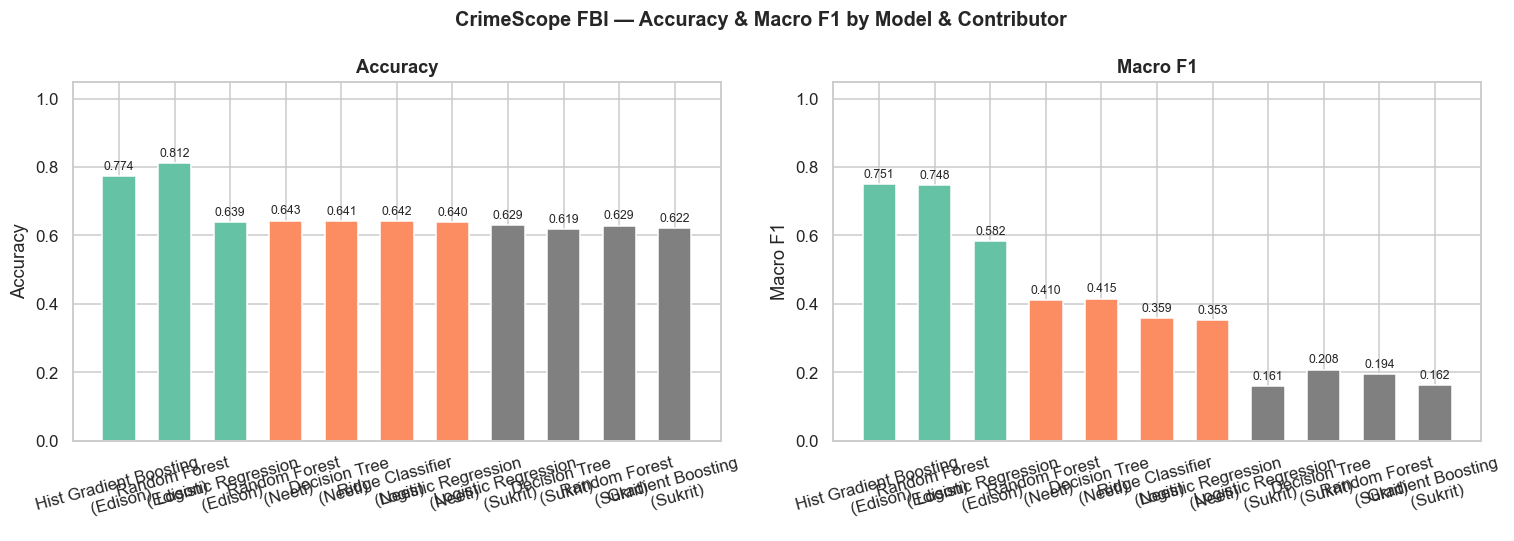

In [17]:
# ── Accuracy & Macro F1 comparison ────────────────────────────────────────
has_acc = all_results.dropna(subset=['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, label in zip(axes,
                           ['accuracy', 'macro_f1'],
                           ['Accuracy', 'Macro F1']):
    sub    = has_acc.dropna(subset=[col])
    labels = sub['model'] + '\n(' + sub['contributor'] + ')'
    colors = [contributor_palette.get(c, 'gray') for c in sub['contributor']]
    bars   = ax.bar(labels, sub[col], color=colors, edgecolor='white', width=0.6)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel(label)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, sub[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('CrimeScope FBI — Accuracy & Macro F1 by Model & Contributor',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'combined_accuracy_f1.png', dpi=150, bbox_inches='tight')
plt.show()


In [18]:
# ── Save all outputs ──────────────────────────────────────────────────────
all_results.to_csv(OUTPUT_DIR / 'combined_model_results.csv', index=False)
print("✅ Results saved to:", OUTPUT_DIR / 'combined_model_results.csv')
print("\n── Output files ──────────────────────────────────────────────────────────")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {f.name}")


✅ Results saved to: model_outputs\combined_model_results.csv

── Output files ──────────────────────────────────────────────────────────
  combined_accuracy_f1.png
  combined_model_results.csv
  combined_roc_auc.png
  eda_crime_against_trends.png
  eda_hour_dist.png
  eda_locations.png
  eda_state_year.png
  eda_top_categories.png
  edison_gradient_boosting.png
  edison_hist_gradient_boosting.png
  edison_logistic_regression.png
  edison_model_comparison.png
  edison_random_forest.png
  fi_neeti_—_decision_tree_feature_importance.png
  khue_forecast_CA.png
  khue_forecast_ID.png
  khue_forecast_MA.png
  khue_forecast_NJ.png
  khue_patrol_allocation.png
  neeti_decision_tree.png
  neeti_logistic_regression.png
  neeti_random_forest.png
  neeti_ridge_classifier.png
  sukrit_cm_decision_tree.png
  sukrit_cm_gradient_boosting.png
  sukrit_cm_logistic_regression.png
  sukrit_cm_random_forest.png
  sukrit_model_comparison.png
